In [87]:
import numpy as np
import pandas as pd
from utils.utils import load_excelfile, generar_estadistica_por_departamento, generarMapaEstadisticaDepartamentos
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
# Abrir el archivo
#archivo = "/home/carbajal/Documents/SaludMental/Datos recibidos en primer instancia.xlsx"
archivo='/home/carbajal/Documents/SaludMental/2da entrega 20260210/Planilla completa.xlsx'

dfs = load_excelfile(archivo)
segunda_entrega = 'EH' in dfs.keys()

## Ejemplo: acceder a una hoja
df_IAE = dfs["IAE"]
df_IAE_CDE = dfs["IAE_CDE"] if 'IAE_CDE' in dfs.keys() else dfs["CDE"]
df_IAE_CNV = dfs["IAE_CNV"] if 'IAE_CNV' in dfs.keys() else dfs["CNV"]
df_IAE_RUCAF = dfs["IAE_RUCAF"] 
df_IAE_SHARPS = dfs["IAE_SHARPS"] if 'IAE_SHARPS' in dfs.keys() else dfs["SHARPS"]
df_IAE_SIV = dfs["IAE_SIV"] if 'IAE_SIV' in dfs.keys() else dfs["SIV"]
df_IAE_EH = dfs["EH"] if 'EH' in dfs.keys() else None
#df_Mort2023 = dfs["Mortalidad2023"]

['IAE', 'CDE', 'CNV', 'EH', 'SIV', 'SHARPS', 'IAE_RUCAF', 'Sheet1']


# Análisis de la base de IAE_CDE  (Certificados de defunción)

In [89]:
df_IAE_CDE.shape  # primera versión tenía 270 filas, ahora 4678

(4678, 16)

In [90]:
df_IAE_CDE = df_IAE_CDE.dropna(thresh=3) # si tiene al menos tres valores no nulos me quedo con las filas


In [91]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4678 entries, 0 to 4677
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           4678 non-null   object        
 1   fecha_defuncion                  4678 non-null   datetime64[ns]
 2   causa_basica_muerte_valor        4663 non-null   object        
 3   causa_basica_muerte_descripcion  4663 non-null   object        
 4   lugar_ocurrencia                 4678 non-null   object        
 5   lugar_ocurrencia_detalle         305 non-null    object        
 6   departamento_ocurrencia          4677 non-null   object        
 7   edad_fallecimiento_calculada     4667 non-null   float64       
 8   edad_fallecimiento_digitada      4668 non-null   float64       
 9   estado_civil                     4670 non-null   object        
 10  etnia                            4678 non-null   object     

In [92]:
np.sum(df_IAE_CDE.duplicated()) # no hay duplicados

np.int64(0)

In [93]:
df_IAE_CDE['etnia'].value_counts()

etnia
BLANCA          4094
SE DESCONOCE     430
AFRO O NEGRA      57
OTRA              56
ASIATICA          23
INDIGENA          18
Name: count, dtype: int64

In [94]:
#df_IAE_CDE['motivo_externo'].value_counts()

In [95]:
aa = df_IAE_CDE['edad_fallecimiento_calculada'] == df_IAE_CDE['edad_fallecimiento_digitada']

In [96]:
df_IAE_CDE[df_IAE_CDE['edad_fallecimiento_calculada']==0]

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc
1488,508d9a741f6e92c8ea1c1c6c4be5b9bea4c4fce106d95c...,2023-09-07,W750,SOFOCACIÓN Y ESTRANGULAMIENTO ACCIDENTAL EN LA...,DOMICILIO,NaN,AR,0.0,0.0,NaN,BLANCA,NaN,NaN,S,OTRO,"lactante que dormia con sus padres , y entorno..."
2762,96ee8cb90b980ccf94009668bea37a56fa7ef92a8dc762...,2023-07-22,W144,"CAÍDA DESDE UN ÁRBOL, CALLES Y CARRETERAS",CENTRO ASISTENCIAL,NaN,MO,0.0,0.0,NaN,BLANCA,NaN,145.0,S,ACCIDENTE,traumatismo de craneo por caida de rama de arbol
3078,ab26547fad7357cee3286ee221a300c59a6a9455c9646c...,2023-10-29,X599,EXPOSICIÓN A FACTORES NO ESPECIFICADOS QUE CAU...,DOMICILIO,NaN,RV,0.0,0.0,NaN,BLANCA,NaN,NaN,S,ACCIDENTE,NaN
3374,bcc139731f614245970c5d1018c055c21f754ffdb8147d...,2025-06-18,W840,"OBSTRUCCIÓN NO ESPECIFICADA DE LA RESPIRACIÓN,...",DOMICILIO,NaN,CO,0.0,0.0,NaN,BLANCA,NaN,NaN,S,ACCIDENTE,NaN
3867,d725bc0cfba3ab2fc3903d51284b8b18086a196ac3a62f...,2024-02-06,W809,INHALACIÓN E INGESTIÓN DE OTROS OBJETOS QUE CA...,CENTRO ASISTENCIAL,NaN,CO,0.0,0.0,NaN,BLANCA,NaN,65.0,N,NaN,NaN
4108,e22d1f526d36e3b56c494b1843bd468487b05a0a752934...,2023-06-07,W799,INHALACIÓN E INGESTIÓN DE ALIMENTO QUE CAUSA O...,CENTRO ASISTENCIAL,NaN,MO,0.0,0.0,NaN,SE DESCONOCE,NaN,117.0,N,NaN,NaN


In [97]:
df_IAE_CDE[df_IAE_CDE['edad_fallecimiento_calculada']==0]

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc
1488,508d9a741f6e92c8ea1c1c6c4be5b9bea4c4fce106d95c...,2023-09-07,W750,SOFOCACIÓN Y ESTRANGULAMIENTO ACCIDENTAL EN LA...,DOMICILIO,NaN,AR,0.0,0.0,NaN,BLANCA,NaN,NaN,S,OTRO,"lactante que dormia con sus padres , y entorno..."
2762,96ee8cb90b980ccf94009668bea37a56fa7ef92a8dc762...,2023-07-22,W144,"CAÍDA DESDE UN ÁRBOL, CALLES Y CARRETERAS",CENTRO ASISTENCIAL,NaN,MO,0.0,0.0,NaN,BLANCA,NaN,145.0,S,ACCIDENTE,traumatismo de craneo por caida de rama de arbol
3078,ab26547fad7357cee3286ee221a300c59a6a9455c9646c...,2023-10-29,X599,EXPOSICIÓN A FACTORES NO ESPECIFICADOS QUE CAU...,DOMICILIO,NaN,RV,0.0,0.0,NaN,BLANCA,NaN,NaN,S,ACCIDENTE,NaN
3374,bcc139731f614245970c5d1018c055c21f754ffdb8147d...,2025-06-18,W840,"OBSTRUCCIÓN NO ESPECIFICADA DE LA RESPIRACIÓN,...",DOMICILIO,NaN,CO,0.0,0.0,NaN,BLANCA,NaN,NaN,S,ACCIDENTE,NaN
3867,d725bc0cfba3ab2fc3903d51284b8b18086a196ac3a62f...,2024-02-06,W809,INHALACIÓN E INGESTIÓN DE OTROS OBJETOS QUE CA...,CENTRO ASISTENCIAL,NaN,CO,0.0,0.0,NaN,BLANCA,NaN,65.0,N,NaN,NaN
4108,e22d1f526d36e3b56c494b1843bd468487b05a0a752934...,2023-06-07,W799,INHALACIÓN E INGESTIÓN DE ALIMENTO QUE CAUSA O...,CENTRO ASISTENCIAL,NaN,MO,0.0,0.0,NaN,SE DESCONOCE,NaN,117.0,N,NaN,NaN


In [98]:
df_IAE_CDE['lugar_ocurrencia'].value_counts()

lugar_ocurrencia
DOMICILIO                2110
CENTRO ASISTENCIAL       1609
OTRO                      480
VÍA PÚBLICA               295
TRABAJO                    67
CASA DE SALUD/ASILO        65
CÁRCEL                     44
AGUAS INTERNACIONALES       4
SE DESCONOCE                4
Name: count, dtype: int64

In [99]:
np.sum(df_IAE_CDE['cedula'].isnull()) # no hay campos vacíos en las cédulas

np.int64(0)

In [100]:
df_IAE_CDE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4678 entries, 0 to 4677
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           4678 non-null   object        
 1   fecha_defuncion                  4678 non-null   datetime64[ns]
 2   causa_basica_muerte_valor        4663 non-null   object        
 3   causa_basica_muerte_descripcion  4663 non-null   object        
 4   lugar_ocurrencia                 4678 non-null   object        
 5   lugar_ocurrencia_detalle         305 non-null    object        
 6   departamento_ocurrencia          4677 non-null   object        
 7   edad_fallecimiento_calculada     4667 non-null   float64       
 8   edad_fallecimiento_digitada      4668 non-null   float64       
 9   estado_civil                     4670 non-null   object        
 10  etnia                            4678 non-null   object     

In [101]:
df_IAE_CDE['causa_basica_muerte_valor'].unique()

array(['X707', 'Y260', 'X849', 'X599', 'R961', 'Y249', 'X708', 'W809',
       'W124', 'W735', 'X590', 'X450', 'Y344', 'X049', 'X700', 'X744',
       'V445', 'X740', 'W740', 'W019', 'W014', 'X701', 'W748', 'W780',
       'X748', 'Y218', 'X640', 'X319', 'X704', 'Y349', 'Y261', 'R99',
       'B209', 'X831', 'X649', 'W789', 'X705', 'W744', 'N179', 'X645',
       'X709', 'X000', 'W844', 'W176', 'X449', 'X659', 'W800', 'X800',
       'B378', 'W849', nan, 'Y340', 'X714', 'X470', 'X610', 'W238',
       'J449', 'X749', 'W206', 'W856', 'X718', 'W798', 'X310', 'X680',
       'W649', 'X840', 'W790', 'J189', 'W870', 'W100', 'X459', 'X745',
       'W060', 'W010', 'Y140', 'K746', 'W130', 'I219', 'W230', 'J849',
       'W199', 'W168', 'W698', 'X230', 'X200', 'F03', 'G931', 'W749',
       'Y348', 'Y300', 'J81', 'X732', 'X619', 'X760', 'X099', 'W840',
       'W874', 'W200', 'W132', 'X702', 'X809', 'J440', 'C169', 'X420',
       'W700', 'C349', 'Y219', 'X730', 'X747', 'X737', 'X479', 'W680',
       'W879

In [102]:
df_IAE_CDE['lugar_ocurrencia'].unique()

array(['OTRO', 'DOMICILIO', 'CENTRO ASISTENCIAL', 'TRABAJO',
       'VÍA PÚBLICA', 'CÁRCEL', 'CASA DE SALUD/ASILO',
       'AGUAS INTERNACIONALES', 'SE DESCONOCE'], dtype=object)

In [103]:
df_IAE_CDE['departamento_ocurrencia'].value_counts()

departamento_ocurrencia
MO    1922
CA     603
MA     268
CO     197
SA     157
PA     155
SJ     150
RV     134
TA     132
RO     123
CL     121
LA     109
SO     109
TT     108
DU     106
AR      91
RN      82
FD      75
FS      35
Name: count, dtype: int64

In [104]:
edades_digitadas = df_IAE_CDE["edad_fallecimiento_digitada"]
print(edades_digitadas)
print(len(edades_digitadas), edades_digitadas.min(), edades_digitadas.max())
print('Valores nulos:',np.sum(edades_digitadas.isnull()))
#edades.value_counts()

0       29.0
1       64.0
2       53.0
3       85.0
4       26.0
        ... 
4673    76.0
4674    86.0
4675    53.0
4676    70.0
4677    63.0
Name: edad_fallecimiento_digitada, Length: 4678, dtype: float64
4678 0.0 106.0
Valores nulos: 10


In [105]:
edades_calculadas = df_IAE_CDE["edad_fallecimiento_calculada"]
print(edades_calculadas)
print(len(edades_calculadas), edades_calculadas.min(), edades_calculadas.max())
print('Valores nulos:',np.sum(edades_calculadas.isnull()))

print(np.sum(edades_calculadas==edades_digitadas))

0       29.0
1        NaN
2       53.0
3       85.0
4       26.0
        ... 
4673    76.0
4674    86.0
4675    53.0
4676    70.0
4677    63.0
Name: edad_fallecimiento_calculada, Length: 4678, dtype: float64
4678 0.0 106.0
Valores nulos: 11
4643


In [106]:
# algunos valores de CIE10 sacados de wikipedia, por ahora no se usan
# en esta base hay mas (R99, J189, E149, etc)
CIE10={'X60':"Envenenamiento analgésicos",'X61':"Envenenamiento sedantes",'X62':"Envenenamiento narcóticos",'X63':"Envenenamiento otras drogas especificadas",'X64':"Envenenamiento otras drogas no especificadas",
       'X65':"Envenenamiento alcohol",'X66':"Envenenamiento hidrocarburos",'X67':"Envenenamiento otros gases",'X68':"Envenenamiento plaguicidas",'X69':"Envenenamiento no específicado",
       'X70':"Ahorcamiento",'X71':"Ahogamiento",'X72':"Disparo arma corta",'X73':"Disparo arma larga",'X74':"Disparo otras armas",
       'X75':"Material Explosivo", 'X76':"Incendio", 'X77':"Vapores", 'X78':"Objeto cortante", 'X79':"Objeto romo",
       'X80':"Salto", 'X81':"Interponerse a vehículo", 'X82':"Colisionar vehículo", 'X83':"Lesión autoinfligida especificada", 'X84':"Lesión autoinfligida no especificada",
       'X85':"Drogas", 'X86':"Sustancia corrosiva", 'X87':"Plaguicida"}

CAT_SUI = ['X60','X61','X62','X63','X64','X65','X66','X67','X68','X69',
           'X70','X71','X72','X73','X74','X75','X76','X77','X78','X79',
           'X80','X81','X82','X83','X84']

CAT_MCEXSUI = ['V00','V01','V02','V03','V04','V05','V06','V07','V08','V09',
           'V10','V11','V12','V13','V14','V15','V16','V17','V18','V19',
           'V20','V21','V22','V23','V24','V25','V26','V27','V28','V29',
           'V30','V31','V32','V33','V34','V35','V36','V37','V38','V39',
           'V40','V41','V42','V43','V44','V45','V46','V47','V48','V49',
           'V50','V51','V52','V53','V54','V55','V56','V57','V58','V59',
           'V60','V61','V62','V63','V64','V65','V66','V67','V68','V69',
           'V70','V71','V72','V73','V74','V75','V76','V77','V78','V79',
           'V80','V81','V82','V83','V84','V85','V86','V87','V88','V89',
           'V90','V91','V92','V93','V94','V95','V96','V97','V98','V99',

           'W00','W01','W02','W03','W04','W05','W06','W07','W08','W09',
           'W10','W11','W12','W13','W14','W15','W16','W17','W18','W19',
           'W20','W21','W22','W23','W24','W25','W26','W27','W28','W29',
           'W30','W31','W32','W33','W34','W35','W36','W37','W38','W39',
           'W40','W41','W42','W43','W44','W45','W46','W47','W48','W49',
           'W50','W51','W52','W53','W54','W55','W56','W57','W58','W59',
           'W60','W61','W62','W63','W64','W65','W66','W67','W68','W69',
           'W70','W71','W72','W73','W74','W75','W76','W77','W78','W79',
           'W80','W81','W82','W83','W84','W85','W86','W87','W88','W89',
           'W90','W91','W92','W93','W94','W95','W96','W97','W98','W99',
           
           'X00','X01','X02','X03','X04','X05','X06','X07','X08','X09',
           'X10','X11','X12','X13','X14','X15','X16','X17','X18','X19',
           'X20','X21','X22','X23','X24','X25','X26','X27','X28','X29',
           'X30','X31','X32','X33','X34','X35','X36','X37','X38','X39',
           'X40','X41','X42','X43','X44','X45','X46','X47','X48','X49',
           'X50','X51','X52','X53','X54','X55','X56','X57','X58','X59',
                                         'X85','X86','X87','X88','X89',
           'X90','X91','X92','X93','X94','X95','X96','X97','X98','X99',
           'Y40','Y41','Y42','Y43','Y44','Y45','Y46','Y47','Y48','Y49',
           'Y50','Y51','Y52','Y53','Y54','Y55','Y56','Y57','Y58','Y59',
           'Y60','Y61','Y62','Y63','Y64','Y65','Y66','Y67','Y68','Y69',
           'Y70','Y71','Y72','Y73','Y74','Y75','Y76','Y77','Y78','Y79',
           'Y80','Y81','Y82','Y83','Y84','Y85','Y86','Y87']

In [107]:
df_IAE_CDE['CAT_SUI_'] =  df_IAE_CDE['causa_basica_muerte_valor'].apply( lambda x : 1 if str(x)[:3] in CAT_SUI else 0)

In [108]:
df_IAE_CDE['CAT_MCEXSUI_'] = df_IAE_CDE['causa_basica_muerte_valor'].apply( lambda x : 1 if str(x)[:3] in CAT_MCEXSUI else 0) 

In [109]:
df_IAE_CDE['causa_basica_muerte_valor'][df_IAE_CDE['CAT_SUI_']==1].shape 

(2181,)

In [110]:
df_IAE_CDE['causa_basica_muerte_valor'].value_counts()

causa_basica_muerte_valor
X700    1187
X590     611
X599     399
X740     246
W849     186
        ... 
W235       1
X618       1
W856       1
B378       1
X659       1
Name: count, Length: 380, dtype: int64

In [111]:
len(df_IAE_CDE['causa_basica_muerte_valor'].unique())  #En el CIE10 hay 1170 categorías, acá se usan 111.  
                                                       # en la segunda versión se usan 381

381

In [112]:
## La base de defunciones no dice el prestador donde se produjo el deceso

In [113]:
def discretizar(df, nombre_original, nombre_nueva, bin_size=5):
    '''
    Discretiza un valur continuo o entero
    numbre original: nombre de la columna que contiene el valor a discretizar
    nombre nuevo: 
    bin_size = ancho de la discretización (Ej: edades cada 5 años)
    '''
    df=df.copy()  # compia para no perder el original
    df[nombre_nueva] = pd.to_numeric(df[nombre_original], errors="raise")
    df[nombre_nueva] = pd.cut(df[nombre_nueva], bins=range(0, int(df[nombre_nueva].max()) + bin_size, bin_size), right=False)

    # usar el valor medio de cada intervalo
    df[nombre_nueva] = df[nombre_nueva].apply(lambda x: x.mid)

    return df

# Agrupar edades de a 5 
df_IAE_CDE = discretizar(df_IAE_CDE, "edad_fallecimiento_calculada", "grupo edades", 5)

# Análisis de la base de IAE  

In [114]:
df_IAE.shape   # 10428 intentos

(19884, 29)

In [115]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19884 entries, 0 to 19883
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15586 non-null  float64       
 1   CEDULA                                     19873 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19351 non-null  object        
 5   FECHA NACIMIENTO                           15047 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15587 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12498 non-null  object        
 9   REGISTRO         

In [116]:
df_IAE[df_IAE['CEDULA'].isna()]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9856,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14800,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15795,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-02-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16802,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-08-15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16826,NaN,NaN,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2025-07-01,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
17315,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-07-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18379,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-09-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18913,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-05-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18933,NaN,NaN,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [117]:
df_IAE = df_IAE.dropna(thresh=4) # se elimina una fila que tenía casi todo Nan (mas de 3)
df_IAE.shape 

(19873, 29)

In [118]:
df_IAE.head()

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
0,895.0,75b770ddbd1a43188f867d9ef8df0980412cb32b12374c...,NaN,NaN,Femenino,2009-09-01 00:00:00,NO CUMPLE PROTOCOLO,UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA,NaN,2023-01-24,...,NO,NaN,NO,NaN,NaN,valentina Acosta,NaN,NaN,NaN,NaN
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,NaN,NaN,Femenino,2002-09-01 00:00:00,RESUELTO,CAMEC,NaN,2023-03-14,...,SI,45021.0,NaN,NaN,NaN,LIC ROMANO,,NaN,NaN,NaN
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,NaN,NaN,Masculino,2006-05-01 00:00:00,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,...,NaN,NaN,NO,NaN,NaN,LIC ROMANO,DRA FERNANDEZ,NaN,NaN,NaN
3,2804.0,6fb148c1f5d374e972746773f234955641ffee740f61f2...,NaN,NaN,Femenino,1952-07-01 00:00:00,PENDIENTE RESPUESTA,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,SANATORIO JUAN PABLO II,2023-06-19,...,NaN,NaN,NaN,NaN,NaN,Valentina Acosta,Envio email al circulo solicitando informacion.,NaN,NaN,NaN
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,NaN,NaN,Femenino,1996-07-01 00:00:00,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,...,NaN,NaN,PEND,NaN,NaN,Valentina Acosta,Me comunico con supervisora de archivos en bus...,NaN,NaN,NaN


In [119]:
np.sum(df_IAE['CEDULA'].isnull())  # existen todas las cédulas

np.int64(0)

In [120]:
df_IAE['CEDULA'].value_counts()

CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64

In [121]:
aa=df_IAE.dropna(thresh=5)

In [122]:
bad = df_IAE[df_IAE.isna().sum(axis=1) > 24]
bad.dropna(axis=1, how='all')

,CEDULA,PERSONA,REGISTRO,METODO
493,e8c474da07e0da4abcf929593a7198bb7bb269c75c2ef3...,Femenino,2023-11-06,"EXPOSICI�N A FACTORES NO ESPECIFICADOS, QUE CA..."
551,6df43fd79182851d547b8eaf01a157d72b05aae6725647...,Masculino,2025-03-22,"AHOGAMIENTO Y SUMERSI�N NO ESPECIFICADOS, CALL..."
610,9de584a52b3e32a2955c85ca70bc05ce0902a2a311bd95...,Femenino,2025-06-27,"INHALACI�N DE CONTENIDOS G�STRICOS, INSTITUCI�..."
641,6d840ad2277fa8282bcc273b23ea0f3f5c5f7c7a1dda20...,Masculino,2024-12-05,EXPOSICI�N A CORRIENTE EL�CTRICA NO ESPECIFICA...
841,0cced34f24b380bd55081bf4414cbbff56f63b56a49bad...,Masculino,2025-11-03,LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...
...,...,...,...,...
19879,ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...,Masculino,2025-01-28,"EVENTO NO ESPECIFICADO, DE INTENCI�N NO DETERM..."
19880,c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...,Masculino,2025-02-18,"EXPOSICI�N A HUMOS, FUEGOS O LLAMAS NO ESPECIF..."
19881,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,Masculino,2025-09-03,EXPOSICI�N A FUEGO NO CONTROLADO EN EDIFICIO U...
19882,fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...,Femenino,2025-10-20,EXPOSICI�N A FUEGO NO CONTROLADO EN EDIFICIO U...


In [123]:
print(df_IAE[df_IAE.isna().sum(axis=1) > 24])

       ID                                             CEDULA  NOMBRE  \
493   NaN  e8c474da07e0da4abcf929593a7198bb7bb269c75c2ef3...     NaN   
551   NaN  6df43fd79182851d547b8eaf01a157d72b05aae6725647...     NaN   
610   NaN  9de584a52b3e32a2955c85ca70bc05ce0902a2a311bd95...     NaN   
641   NaN  6d840ad2277fa8282bcc273b23ea0f3f5c5f7c7a1dda20...     NaN   
841   NaN  0cced34f24b380bd55081bf4414cbbff56f63b56a49bad...     NaN   
...    ..                                                ...     ...   
19879 NaN  ca22ff093b04f0c7b98744c37337fabce487dcefeaebf3...     NaN   
19880 NaN  c8426aa7f35f46523c1aded3048e5ca01179c5faf5131c...     NaN   
19881 NaN  169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...     NaN   
19882 NaN  fb411d4bf124deb8bffd3b6c1265a7ca09fab1dfc92af1...     NaN   
19883 NaN  8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa4229...     NaN   

       APELLIDO    PERSONA FECHA NACIMIENTO DECISION PRESTADOR  \
493         NaN   Femenino              NaN      NaN       NaN   
551

In [124]:
df_IAE.shape, aa.shape

((19873, 29), (15587, 29))

In [125]:
df_IAE[df_IAE['CEDULA'].isnull()]

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO


## Duplicados IAE

In [126]:
df_IAE.drop_duplicates(inplace=True)  # en la primera entrega de datos 10 valores están duplicados y se eliminan
                                      # en la segunda entrega hay 2 valores están duplicados y se eliminan 
df_IAE.shape

/tmp/ipykernel_82755/953818204.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE.drop_duplicates(inplace=True)  # en la primera entrega de datos 10 valores están duplicados y se eliminan


(19871, 29)

In [127]:
np.sum(df_IAE.duplicated())

np.int64(0)

In [128]:
# hay 6 pares de IAE que difieren solo en los campos REGISTRO y/o ESTABLECIMIENTO REGISTRO (no hago nada con ellos)
# uno par ocurrió el mismo día
cols_igual = [c for c in df_IAE.columns if c not in ['CEDULA']]
duplicados = df_IAE[df_IAE.duplicated(subset=cols_igual, keep=False)]
duplicados


,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
1248,NaN,566b24121540063056c99a9e5f21d46298f1ef06d2b9e2...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2024-03-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1664,NaN,474a9dbbb9049677aedf5d94c56ab710b7becf5999ac0f...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2023-02-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2281,NaN,8c44641556a640414cffd6c2d269209c768bbaaec25090...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-08-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2377,NaN,cfb1089c579697aa499b02722c4419c864cf69bcf23b41...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2023-10-04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2408,NaN,c7dc460b83b3a910acdc46d84278062d1a43153cbe4f42...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-03-12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19874,NaN,244ca99583a57fad470632953ef189b3a0b107e5a6ab24...,NaN,NaN,Femenino,NaN,NaN,NaN,NaN,2024-08-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19876,NaN,98e26372fda64edd90d4162edc52c72c47a7a6cb87cd29...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-10-22,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19878,NaN,027162a9958d97d725ed440a4d9166e0244abc8d084ed0...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2024-12-27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19881,NaN,169d68340bd6eab354ec7ce8ea1d7f6dad739167bb3bf4...,NaN,NaN,Masculino,NaN,NaN,NaN,NaN,2025-09-03,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15584 non-null  float64       
 1   CEDULA                                     19871 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19340 non-null  object        
 5   FECHA NACIMIENTO                           15045 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15585 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12496 non-null  object        
 9   REGISTRO              

In [130]:
df_IAE['MOTIVO'].value_counts()

MOTIVO
1.0        7
7.0        3
4.0        2
45100.0    1
45121.0    1
3.0        1
Name: count, dtype: int64

In [131]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 29 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15584 non-null  float64       
 1   CEDULA                                     19871 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19340 non-null  object        
 5   FECHA NACIMIENTO                           15045 non-null  object        
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15585 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12496 non-null  object        
 9   REGISTRO              

In [132]:
len(df_IAE['CEDULA'].unique())  # 8827 personas en la base

16665

In [133]:
df_IAE['CEDULA'].value_counts()  # dos personas con 10 intentos

CEDULA
e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a    16
228f1c59f6ccfc954920d227db9bf3a747fb989c06e1e817a9932777098e140f    13
15b386c21fa56d4187b20c7903269000505a596fbda3f62074b72822cffde86b    13
6f343891fb7d579858b87ecf0b6e8b44f1d15395822600355be8dcaae39c4362    12
e1be0faa774f043efdd0942cb03ee79a0c626167b05d47b055ae0bf6018cda96    12
                                                                    ..
8dbb4462902d4093cb9914105af2607b0240b45bfbbbc042806bd7a2c35c0660     1
bb15bbcc55540e176b92c82691a100b7f2ac69543183b4622cd79bdc3cf8a724     1
cf65782e4eb1ce87b5335fac88b8cd9b7c275e913661bb913cd710a867b723bc     1
8bf49c12b8ffc3a9bcd4063ca67f8cd2a71f7a1afa422958a74b877cdede2d56     1
1d695ce2c0ac60da4d59e890e1e36d96af23b50be11b6a91af5105f276a22a7b     1
Name: count, Length: 16665, dtype: int64

In [134]:
df_IAE[df_IAE['CEDULA']=='e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a8a821087b340fa1a2a']

,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,AGENDO NUEVA CONSULTA,FECHA DE NUEVA CONSULTA,INTERNACION,FECHA ALTA,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO
1780,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-02-21,...,NaN,NaN,NaN,NaN,NO,NaN,Valentina Acosta,NaN,NaN,NaN
2606,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-06-25,...,NaN,NaN,NaN,NaN,SI,45470,Valentina Acosta,NaN,NaN,NaN
3702,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,RESUELTO,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2024-09-03,...,NaN,NaN,NaN,NaN,SI,45542,LIC ROMANO - Valentina Acosta,N,NaN,NaN
6481,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-07,...,NaN,NaN,NaN,NaN,NO,NaN,LIC ROMANO - Valentina Acosta,N,NaN,NaN
6501,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-10,...,NaN,NaN,NaN,NaN,SI,45696,LIC ROMANO - Valentina Acosta,N,NaN,NaN
6635,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,NaN,NaN,NaN,CAMEC,CAMEC,2025-02-17,...,NaN,NaN,NaN,NaN,NO,NaN,LIC ROMANO,N,NaN,NaN
7142,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-03-18,...,NaN,NaN,NaN,NaN,SI,45735,LIC ROMANO - Valentina Acosta,NaN,NaN,NaN
7662,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-04-15,...,NaN,NaN,NaN,NaN,SI,45763,LIC ROMANO,N,NaN,NaN
8360,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-05-30,...,NaN,NaN,NaN,NaN,SI,45812,lic romano,NaN,NaN,NaN
8790,695.0,e767b4c92d67814d5fd3c38124c2fedb12fb2534a0640a...,NaN,NaN,Femenino,1971-04-01 00:00:00,NaN,CAMEC,SEDE PRINCIPAL - SANATORIO ROSARIO,2025-06-30,...,NaN,NaN,NaN,NaN,SI,45839,LIC ROMANO - Valentina Acosta,NaN,NaN,NaN


In [135]:
df_IAE['PERSONA'].value_counts()

PERSONA
Femenino              12294
Masculino              7042
Indefinido                2
FemeninF1110:F1182        1
NO C                      1
Name: count, dtype: int64

In [136]:
def etiquetar_prestador(institucion):
    ''' 
    Si dice ASSE, POLICIAL, FUERZAS ARMADAS o CLINICAS etiqueto como Pública, si no Privada
    '''
    if 'ASSE' in institucion or 'POLICIAL' in institucion or 'FUERZAS ARMADAS' in institucion or 'CLINICAS' in institucion:
        return 'Pública'
    else:
        return 'Privada'

def tipo_prestador_IAE(institucion):
    ''' 
    Etiqueta los prestadores asociados a un IAE. Puede haber varios prestadores asociados al intento. Se separan por el símbolo "|".
    Ej: Si hay varios prestadores podría devolver: "Pública | Privada | Pública" o "Privada | Pública"
    '''
    if institucion=='No indicado':
        return institucion
    elif institucion == 'NaN' or pd.isna(institucion):
        return 'nan'
    elif '|' in institucion:
        instituciones =  institucion.split('|')
        etiqueta = [etiquetar_prestador(inst) for inst in instituciones]
        etiqueta = '|'.join(etiqueta)
        #print(institucion, etiqueta)
        return etiqueta
    else:
        return etiquetar_prestador(institucion)

In [137]:
# Se crea una nueva columna con los tipos de prestador
if segunda_entrega:
    df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR'].copy()
    df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR'].apply(lambda x: tipo_prestador_IAE(x) if pd.notnull(x) else np.nan)
else:
    df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR RECODIFICADO'].copy()
    df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR RECODIFICADO'].apply(lambda x: tipo_prestador_IAE(x) if pd.notnull(x) else np.nan)

df_IAE['Tipo prestador IAE'] 

/tmp/ipykernel_82755/94081708.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR'].copy()
/tmp/ipykernel_82755/94081708.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['Tipo prestador IAE'] = df_IAE['PRESTADOR'].apply(lambda x: tipo_prestador_IAE(x) if pd.notnull(x) else np.nan)


0        Privada
1        Privada
2        Privada
3        Privada
4        Privada
          ...   
19879        NaN
19880        NaN
19881        NaN
19882        NaN
19883        NaN
Name: Tipo prestador IAE, Length: 19871, dtype: object

In [138]:
df_IAE['Tipo prestador IAE'].unique()

array(['Privada', 'Pública|Pública', 'Pública', 'Privada|Pública',
       'Privada|Privada', nan, 'Privada|Pública|Pública',
       'Pública|Privada', 'Privada|Pública|Privada',
       'Privada|Privada|Privada', 'Pública|Pública|Privada',
       'Privada|Privada|Pública|Pública', 'Privada|Privada|Pública',
       'Privada|Privada|Privada|Privada', 'Pública|Privada|Privada',
       'Pública|Pública|Pública'], dtype=object)

In [139]:
# Se crea una variable booleana que indica si tiene asociado al menos un prestador público o no 
df_IAE['PRESTADOR_PUBLICO_'] = df_IAE['Tipo prestador IAE'].apply(lambda x: 'Pública' in x if pd.notnull(x) else np.nan)
df_IAE['PRESTADOR_PRIVADO_'] = df_IAE['Tipo prestador IAE'].apply(lambda x: 'Privada' in x if pd.notnull(x) else np.nan) 

/tmp/ipykernel_82755/1410467662.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['PRESTADOR_PUBLICO_'] = df_IAE['Tipo prestador IAE'].apply(lambda x: 'Pública' in x if pd.notnull(x) else np.nan)
/tmp/ipykernel_82755/1410467662.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['PRESTADOR_PRIVADO_'] = df_IAE['Tipo prestador IAE'].apply(lambda x: 'Privada' in x if pd.notnull(x) else np.nan)


In [140]:
#df_IAE['PRESTADOR RECODIFICADO'][df_IAE['PRESTADOR RECODIFICADO'].isnull()]
#df_IAE['PRESTADOR'][df_IAE['PRESTADOR'].isnull()]

In [141]:
dfs.keys()

dict_keys(['IAE', 'CDE', 'CNV', 'EH', 'SIV', 'SHARPS', 'IAE_RUCAF', 'Sheet1'])

In [142]:
# Guardo todos los prestadores que aparecen en la tabla en una archivo para que quede. Quizás haya repetidos con pequeñas diferencias.
if segunda_entrega:
    nombre_prestadores = 'prestadores_2a_entrega.csv'
    campo_prestador = 'PRESTADOR'
else:
    nombre_prestadores = 'prestadores.csv'
    campo_prestador = 'PRESTADOR RECODIFICADO'

with open(nombre_prestadores,'w') as f:
    
    for i, prestador in enumerate(df_IAE[campo_prestador].unique()):
        print(i, prestador)
        f.write(f'{prestador}, {tipo_prestador_IAE(prestador)} \n')
f.close()

0 UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA
1 CAMEC
2 MEDICA URUGUAYA MUCAM
3 CIRCULO CATOLICO DE OBREROS DEL URUGUAY
4 CUDAM
5 CASMU
6 ASSE - MONTEVIDEO | DIRECCION NACIONAL DE SANIDAD DE LAS FUERZAS ARMADAS
7 ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
8 ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS
9 GREMCA - GREMIAL MEDICA CENTRO ASISTENCIAL
10 SERVICIO MEDICO INTEGRAL SMI
11 ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO | ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
12 CRAMI IAMPP
13 COMEPA
14 CAMCEL
15 CRAME
16 CAAMEPA IAMPP
17 CAMCEL | ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO
18 AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL DE MALDONADO IAMPP
19 HOSPITAL BRITANICO
20 ASSE - SD
21 CAMS IAMPP - CENTRO ASISTENCIAL MEDICO DE SORIANO IAMPP
22 ASSE - HOSPITAL PAYSANDU
23 ASSE - JARDINES DEL HIPODROMO
24 ASSE - HOSPITAL DE CERRO LARGO
25 ASSE - YOUNG
26 COMERO
27 COMECA IAMPP
28 ASSE - MDEO
29 ASSE - BADANO REPETTO
30 CAMCEL | DIRECCION NAC

In [154]:
df_IAE['ESTABLECIMIENTO REGISTRO'].value_counts()

ESTABLECIMIENTO REGISTRO
HOSPITAL PASTEUR                                                          909
CENTRAL                                                                   733
HOSPITAL DEPARTAMENTAL DE PAYSANDU - ESCUELA DEL LITORAL GALAN Y ROCHA    646
SANATORIO                                                                 505
HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO RIVERO MORENO               464
                                                                         ... 
5                                                                           1
IAC Y ASSE TREINTA Y TRES                                                   1
CANTEGRIL                                                                   1
ASSE - PASTEUR                                                              1
PIRIAPOLIS                                                                  1
Name: count, Length: 219, dtype: int64

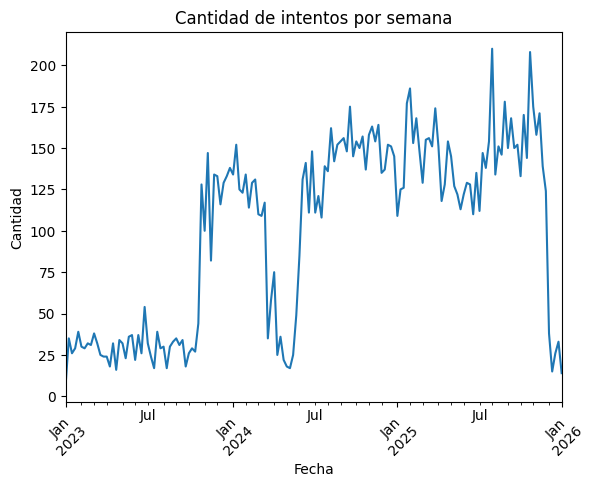

In [155]:
df_IAE['REGISTRO'].value_counts()
#conteo = df_IAE['REGISTRO'].dt.date.value_counts().sort_index() # por día
conteo_semanal = df_IAE.set_index('REGISTRO').resample('W').size()

plt.figure()
conteo_semanal.plot()
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.title("Cantidad de intentos por semana")
plt.xticks(rotation=45)
plt.show()

In [171]:
df_IAE['METODO'].unique()

array(['Lesiones autoinfligidas', 'Ingesta de Medicamentos', 'Otros',
       'Armas de fuego', 'Ahorcamiento o asfixia', nan, '0',
       'Ahogamiento',
       'INHALACI�N DE CONTENIDOS G�STRICOS, INSTITUCI�N RESIDENCIAL',
       'EXPOSICI�N A CORRIENTE EL�CTRICA NO ESPECIFICADA, VIVIENDA',
       'Fuego',
       'ENVENENAMIENTO ACCIDENTAL POR, Y EXPOSICI�N AL ALCOHOL, LUGAR NO ESPECIFICADO',
       'EVENTO NO ESPECIFICADO, DE INTENCI�N NO DETERMINADA, VIVIENDA',
       'SANATORIO DURAZNO',
       'EVENTO NO ESPECIFICADO, DE INTENCI�N NO DETERMINADA, INSTITUCI�N RESIDENCIAL',
       'SI', 'NO', 'CA�DA NO ESPECIFICADA, LUGAR NO ESPECIFICADO',
       'EXPOSICI�N AL FR�O NATURAL EXCESIVO, VIVIENDA',
       'CA�DA EN EL MISMO NIVEL POR DESLIZAMIENTO, TROPEZ�N Y TRASPI�, LUGAR NO ESPECIFICADO',
       'EVENTO NO ESPECIFICADO, DE INTENCI�N NO DETERMINADA, LUGAR NO ESPECIFICADO',
       'Ahorcamiento o asfixia / ingesta de medicamentos', 'SI ', 'otros',
       'INHALACI�N E INGESTI�N DE OTROS

In [210]:
df_IAE['METODO'].value_counts().head(20)

METODO
Ingesta de Medicamentos                                                                        10916
Ahorcamiento o asfixia                                                                          3066
Otros                                                                                           2522
Lesiones autoinfligidas                                                                         1551
Armas de fuego                                                                                   429
Caída                                                                                            184
Fuego                                                                                            162
Ahogamiento                                                                                      136
Envenenamiento autoinfligido intencionalmente                                                     83
Envenenamiento accidental                                                           

In [181]:
def obtener_palabras_en_campo_que_contienen_substr(campo, substr):
    filas = df_IAE[campo].apply(lambda x: substr in x if not pd.isnull(x) else False )
    palabras = df_IAE[campo][filas==True]
    palabras_unicas = palabras.unique()
    return palabras_unicas

In [209]:
df_IAE['METODO'] = df_IAE['METODO'].str.replace("OBSTRUCCI�N", 'OBSTRUCCIÓN')
df_IAE['METODO'] = df_IAE['METODO'].str.replace("CA�DA","CAÍDA")
df_IAE['METODO'] = df_IAE['METODO'].str.replace("RESPIRACI�N", "RESPIRACIÓN")
df_IAE['METODO'] = df_IAE['METODO'].str.replace("INGESTI�N", "INGESTIÓN")
df_IAE['METODO'] = df_IAE['METODO'].str.replace("INHALACI�N", "INHALACIÓN")
df_IAE['METODO'] = df_IAE['METODO'].str.replace("V�AS", "VÍAS")
df_IAE['METODO'] = df_IAE['METODO'].str.replace("EXPOSICI�N", "EXPOSICIÓN")
df_IAE['METODO'] = df_IAE['METODO'].str.replace("G�STRICOS", "GÁSTRICOS")
df_IAE['METODO'] = df_IAE['METODO'].str.replace("EL�CTRICA", "ELÉCTRICA")
df_IAE['METODO'] = df_IAE['METODO'].str.replace("FR�O", "FRÍO")
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','AHORCAMIENTO')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Ahorcamiento o asfixia')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','ARMAS DE FUEGO')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Armas de fuego')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','Arma de fuego')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Armas de fuego')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','AUTOINFLIGIDA')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Lesiones autoinfligidas')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','FACTORES NO ESPECIFICADOS')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Otros')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','NO ESPECIFICADA DE LA RESPIRACIÓN')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Ahorcamiento o asfixia')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','OBSTRUCCIÓN DE LAS VÍAS RESPIRATORIAS')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Ahorcamiento o asfixia')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','AHOGAMIENTO Y SUMERSI')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Ahogamiento')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','FUEGO')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Fuego')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','CAÍDA')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Caída')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','ENVENENAMIENTO AUTOINFLIGIDO INTENCIONALMENTE')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Envenenamiento autoinfligido intencionalmente')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','ENVENENAMIENTO ACCIDENTAL')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Envenenamiento accidental')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','ENVENENAMIENTO')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Envenenamiento')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','EVENTO NO ESPECIFICADO')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Otros')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','INHALACIÓN DE CONTENIDOS GÁSTRICOS')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Inhalación de contenidos gástricos')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','CORRIENTE ELÉCTRICA')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Corriente eléctrica')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('METODO','EXPOSICIÓN AL FRÍO NATURAL')
df_IAE['METODO'] = df_IAE['METODO'].replace(palabras_a_reemplazar,'Frío Natural')
palabras_a_reemplazar

/tmp/ipykernel_82755/1143610074.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['METODO'] = df_IAE['METODO'].str.replace("OBSTRUCCI�N", 'OBSTRUCCIÓN')
/tmp/ipykernel_82755/1143610074.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['METODO'] = df_IAE['METODO'].str.replace("CA�DA","CAÍDA")
/tmp/ipykernel_82755/1143610074.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

array([], dtype=object)

In [212]:
df_IAE["METODO"] = df_IAE["METODO"].replace("otros", "Otros")

/tmp/ipykernel_82755/4290262893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE["METODO"] = df_IAE["METODO"].replace("otros", "Otros")


In [213]:
df_IAE['METODO'].value_counts()

METODO
Ingesta de Medicamentos                                                                           10916
Ahorcamiento o asfixia                                                                             3066
Otros                                                                                              2523
Lesiones autoinfligidas                                                                            1551
Armas de fuego                                                                                      429
                                                                                                  ...  
OTROS EVENTOS ESPECIFICADOS, DE INTENCI�N NO DETERMINADA, INSTITUCI�N RESIDENCIAL                     1
EXPOSICIÓN A OTRAS FUERZAS MEC�NICAS INANIMADAS, Y LAS NO ESPECIFICADAS, LUGAR NO ESPECIFICADO        1
EXPLOSI�N Y ROTURA DE NEUM�TICO, TUBO O MANGUERA DE GOMA PRESURIZADA, CALLES Y CARRETERAS             1
PRIVACI�N DE ALIMENTOS, VIVIENDA                         

In [214]:
categorias = ['Ingesta de Medicamentos', 'Ahorcamiento o asfixia','Lesiones autoinfligidas', 'Armas de fuego', 'Caída']
df_IAE['METODO_'] = df_IAE['METODO'].where(df_IAE['METODO'].isin(categorias), 'Otros')

/tmp/ipykernel_82755/136022868.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['METODO_'] = df_IAE['METODO'].where(df_IAE['METODO'].isin(categorias), 'Otros')


In [215]:
df_IAE['METODO_'].value_counts()

METODO_
Ingesta de Medicamentos    10916
Otros                       3725
Ahorcamiento o asfixia      3066
Lesiones autoinfligidas     1551
Armas de fuego               429
Caída                        184
Name: count, dtype: int64

In [232]:
df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].str.strip() # Elimino espacios antes y después de los string
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr('IAE PREVIO','Tratamiento')
df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace(palabras_a_reemplazar,'Tratamiento')
df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace('Sin dato','NO SE INDICA')
df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace('','NO SE INDICA')
df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].fillna("NO SE INDICA")
df_IAE['IAE PREVIO'].value_counts()

/tmp/ipykernel_82755/2771312954.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].str.strip() # Elimino espacios antes y después de los string
/tmp/ipykernel_82755/2771312954.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['IAE PREVIO'] = df_IAE['IAE PREVIO'].replace(palabras_a_reemplazar,'Tratamiento')
/tmp/ipykernel_82755/2771312954.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

IAE PREVIO
SI              7808
NO SE INDICA    7104
NO              4834
Tratamiento      125
Name: count, dtype: int64

In [233]:
df_IAE['IAE PREVIO'].unique()

array(['NO SE INDICA', 'SI', 'NO', 'Tratamiento'], dtype=object)

In [234]:
df_IAE['IAE PREVIO'].unique()

array(['NO SE INDICA', 'SI', 'NO', 'Tratamiento'], dtype=object)

In [235]:
print(len(df_IAE[df_IAE['IAE PREVIO']=='SI']), 'tuvieron un IAE previo')
df_IAE[df_IAE['IAE PREVIO']=='SI']

7808 tuvieron un IAE previo


,ID,CEDULA,NOMBRE,APELLIDO,PERSONA,FECHA NACIMIENTO,DECISION,PRESTADOR,ESTABLECIMIENTO REGISTRO,REGISTRO,...,FECHA LLAMADA PRESTADOR.1,MSP,OBSERVACIONES,UNNAMED: 26,FECHA DE LLAMADA AL PRESTADOR,MOTIVO,Tipo prestador IAE,PRESTADOR_PUBLICO_,PRESTADOR_PRIVADO_,METODO_
1,1507.0,f5138e15e53b4df18a439fd908b90d42c88c708280daac...,NaN,NaN,Femenino,2002-09-01 00:00:00,RESUELTO,CAMEC,NaN,2023-03-14,...,NaN,LIC ROMANO,,NaN,NaN,NaN,Privada,False,True,Ingesta de Medicamentos
2,2677.0,919938e34174fd08e1fd49e678fc985160d058c6ea74d4...,NaN,NaN,Masculino,2006-05-01 00:00:00,RESUELTO,MEDICA URUGUAYA MUCAM,NaN,2023-06-08,...,NaN,LIC ROMANO,DRA FERNANDEZ,NaN,NaN,NaN,Privada,False,True,Otros
4,2805.0,182eafb797ccb4f8a55b932370740d5ab89093978223ae...,NaN,NaN,Femenino,1996-07-01 00:00:00,PENDIENTE RESPUESTA,CUDAM,CENTRAL,2023-06-19,...,NaN,Valentina Acosta,Me comunico con supervisora de archivos en bus...,NaN,NaN,NaN,Privada,False,True,Ingesta de Medicamentos
5,2806.0,8b2d55e33d23be0a107b9f7a07c61677644face1cc4c99...,NaN,NaN,Masculino,2006-02-01 00:00:00,RESUELTO,CASMU,SANATORIO 2 Urgencia,2023-06-19,...,NaN,LIC ROMANO,DR RICHI,NaN,NaN,NaN,Privada,False,True,Ingesta de Medicamentos
8,2809.0,42460f068be30099444b41e1a3a8913c40b4117a5524c1...,NaN,NaN,Femenino,1979-05-01 00:00:00,NaN,ASSE - MONTEVIDEO | DIRECCION NACIONAL DE SANI...,(Sin institución),2023-06-20,...,NaN,NaN,NaN,NaN,NaN,NaN,Pública|Pública,True,False,Ingesta de Medicamentos
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15659,3581.0,359d177c3239ad703352a370ad559bd29fc48641d41565...,NaN,NaN,Femenino,1987-04-01 00:00:00,RESUELTO,SMQS - SOCIEDAD MEDICA QUIRURGICA DE SALTO - CAM,NaN,NaT,...,45180,Valentina Acosta,NaN,NaN,NaN,NaN,Privada,False,True,Ingesta de Medicamentos
15660,3582.0,81518cb2582d8501b95b722ad4ac222917d37a156e664f...,NaN,NaN,Femenino,2007-08-01 00:00:00,NO CUMPLE PROTOCOLO,ASSE - CANELONES,CENTRO DE SALUD MONTERREY,NaT,...,NaN,LIC ROMANO - Valentina Acosta,CENTRO DE SALUD MONTE REY,NaN,NaN,NaN,Pública,True,False,Ingesta de Medicamentos
15661,6773.0,478aa7e2883d619deefaf09325de4a5631c107deef8729...,NaN,NaN,Masculino,1986-12-01 00:00:00,SIN RESPUESTA,ASSE - MALDONADO,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,Pública,True,False,Otros
15662,6153.0,886daabae5dcade67ada65f70728afcb7928400af14062...,NaN,NaN,Femenino,2009-06-01 00:00:00,SIN RESPUESTA,ASSE - MALDONADO,HOSPITAL DEPARTAMENTAL DE MALDONADO DR. ELBIO ...,NaT,...,NaN,NaN,NaN,NaN,NaN,NaN,Pública,True,False,Ingesta de Medicamentos


In [236]:
df_IAE['FECHA IAE'].unique()

<DatetimeArray>
['2023-01-20 00:00:00', '2023-03-13 00:00:00', '2023-08-06 00:00:00',
 '2023-06-19 00:00:00', '2023-06-18 00:00:00', '2023-06-20 00:00:00',
 '2023-06-21 00:00:00', '2023-06-22 00:00:00', '2023-06-25 00:00:00',
 '2023-06-26 00:00:00',
 ...
 '2023-05-28 00:00:00', '2023-07-28 00:00:00', '2023-03-29 00:00:00',
 '2023-05-29 00:00:00', '2023-07-29 00:00:00', '2024-04-27 00:00:00',
 '2024-04-28 00:00:00', '2024-04-26 00:00:00', '2024-04-24 00:00:00',
 '2023-05-30 00:00:00']
Length: 1025, dtype: datetime64[ns]

In [239]:
campo_nacimiento = 'FECHA NACIMIENTO' if segunda_entrega else 'NACIMIENTO'
pd.isnull(df_IAE[campo_nacimiento])

0        False
1        False
2        False
3        False
4        False
         ...  
19879     True
19880     True
19881     True
19882     True
19883     True
Name: FECHA NACIMIENTO, Length: 19871, dtype: bool

In [240]:
df_IAE['FECHA IAE'] = pd.to_datetime(df_IAE['FECHA IAE'], errors='coerce')
df_IAE[campo_nacimiento] = pd.to_datetime(df_IAE[campo_nacimiento], errors='coerce')
df_IAE['EDAD_'] = df_IAE['FECHA IAE'].dt.year - df_IAE[campo_nacimiento].dt.year

/tmp/ipykernel_82755/2819719607.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE['FECHA IAE'] = pd.to_datetime(df_IAE['FECHA IAE'], errors='coerce')
/tmp/ipykernel_82755/2819719607.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_IAE[campo_nacimiento] = pd.to_datetime(df_IAE[campo_nacimiento], errors='coerce')
/tmp/ipykernel_82755/2819719607.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

In [241]:
df_IAE['EDAD_'].max()

np.float64(113.0)

In [242]:
campo_edad = 'EDAD_' if 'EH' in dfs.keys() else 'EDAD' 
edades_IAE = df_IAE[campo_edad].unique()
print(edades_IAE)
print(np.nanmin(edades_IAE), np.nanmax(edades_IAE))
print(np.sum(np.isnan(edades_IAE)))

[ 14.  21.  17.  71.  27.  37.  53.  44.  32.  23.  49.  48.  82.  16.
  13.  24.  19.  63.  18.  25.  38.  41.  55.  33.  28.  20.  56.  47.
  15.  45.  35.  26.  62.  31.  58.  30.  61.  66.  29.  42.  52.  36.
  76.  nan  60.  54.  22.  12.  69.  34.   0.  65.  11.  39.  57.  77.
  67.  87.  43.  64.  46.  51.  86.  50.  40.  70.  59.  10.  73.  85.
  80.  79.  78.  72.  74.  84.   7.  68.  94.  89.  91.  81.  90. 103.
  88.  95.  98.  75.  83.   8.   9.  93.  96.  92.   2.   3. 113.   6.]
0.0 113.0
1


In [243]:
df_IAE = discretizar(df_IAE, campo_edad, "GRUPO_EDAD_", 5)

In [246]:
# como esta columna contiene información del resultado (Suicidio o no), me quedan dudas de si es conveniente usarla para predecir. 
# Llama la aención la cantidad de casos en que no se cumple protocolo

campo_decision = 'DECISION' if 'EH' in dfs.keys() else 'DECISIÓN'
df_IAE[campo_decision] = df_IAE[campo_decision].str.strip() #saco espacios adelante y atras
df_IAE[campo_decision].value_counts()

DECISION
RESUELTO                               5887
NO CUMPLE PROTOCOLO                    2279
PENDIENTE RESPUESTA                     757
SIN RESPUESTA                           460
SIN RESPUESTA DEFINITIVA                136
INTERNADO                                64
SIN COBERTURA ASISTENCIAL                59
SUICIDIO                                 45
PENDEINTE RESPUESTA                       7
SIN DATOS ASISTENCIALES                   5
PENDIENTE INTERNADO                       3
NO CUMPLE CON PROTOCOLO                   1
NO CUMPLE                                 1
INTERNADA                                 1
RESPUESTA                                 1
PRIVADO DE LIBERTAD                       1
RESUELT0                                  1
FECHA ERRONEA DE IAE? UN AÑO ATRASO       1
SEG PARTICULAR                            1
Name: count, dtype: int64

In [247]:

#filas_unicas

In [248]:
# se agrupan las decisiones
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('RESUELT0','RESUELTO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('RESUELTO ','RESUELTO')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'RESUELTO')
df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'RESUELTO')

palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'NO CUMPLE')
df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'NO CUMPLE PROTOCOLO')

palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'SUICIDIO')
df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'SUICIDIO')

palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'INTERNAD')
df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'INTERNADO')
#df_IAE[campo_decision] = df_IAE[campo_decision].replace('INTERNADO ','INTERNADO')
df_IAE[campo_decision] = df_IAE[campo_decision].replace('PENDIENTE INTERNADO','INTERNADO')

palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'PENDIENTE RESPUESTA')
df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'PENDIENTE RESPUESTA')
palabras_a_reemplazar = obtener_palabras_en_campo_que_contienen_substr(campo_decision,'PENDEINTE RESPUESTA')
df_IAE[campo_decision] = df_IAE[campo_decision].replace(palabras_a_reemplazar,'PENDIENTE RESPUESTA')

df_IAE[campo_decision] = df_IAE[campo_decision].replace('SIN RESPUESTA DEFINITIVA','PENDIENTE RESPUESTA')
df_IAE[campo_decision] = df_IAE[campo_decision].replace('SIN RESPUESTA','PENDIENTE RESPUESTA')
df_IAE[campo_decision].unique()

array(['NO CUMPLE PROTOCOLO', 'RESUELTO', 'PENDIENTE RESPUESTA', nan,
       'INTERNADO', 'SIN COBERTURA ASISTENCIAL', 'SUICIDIO',
       'SIN DATOS ASISTENCIALES', 'RESPUESTA', 'PRIVADO DE LIBERTAD',
       'RESUELT0', 'FECHA ERRONEA DE IAE? UN AÑO ATRASO',
       'SEG PARTICULAR'], dtype=object)

In [358]:
df_IAE[campo_decision].value_counts()

DECISION
RESUELTO                               5887
NO CUMPLE PROTOCOLO                    2281
PENDIENTE RESPUESTA                    1360
INTERNADO                                68
SIN COBERTURA ASISTENCIAL                59
SUICIDIO                                 45
SIN DATOS ASISTENCIALES                   5
RESPUESTA                                 1
PRIVADO DE LIBERTAD                       1
RESUELT0                                  1
FECHA ERRONEA DE IAE? UN AÑO ATRASO       1
SEG PARTICULAR                            1
Name: count, dtype: int64

In [249]:
# se crea una nueva columna DECISION_ con 6 categorías.
df_IAE['DECISION_'] = df_IAE[campo_decision].copy()

categorias = ['RESUELTO', 'NO CUMPLE PROTOCOLO','PENDIENTE RESPUESTA','INTERNADO', 'SUICIDIO']
df_IAE['DECISION_'] = df_IAE['DECISION_'].where(df_IAE['DECISION_'].isin(categorias), 'OTRA DECISION')


In [250]:
df_IAE[campo_decision].unique()

array(['NO CUMPLE PROTOCOLO', 'RESUELTO', 'PENDIENTE RESPUESTA', nan,
       'INTERNADO', 'SIN COBERTURA ASISTENCIAL', 'SUICIDIO',
       'SIN DATOS ASISTENCIALES', 'RESPUESTA', 'PRIVADO DE LIBERTAD',
       'RESUELT0', 'FECHA ERRONEA DE IAE? UN AÑO ATRASO',
       'SEG PARTICULAR'], dtype=object)

In [251]:
df_IAE['DECISION_'].unique()

array(['NO CUMPLE PROTOCOLO', 'RESUELTO', 'PENDIENTE RESPUESTA',
       'OTRA DECISION', 'INTERNADO', 'SUICIDIO'], dtype=object)

In [252]:
df_IAE[campo_decision].value_counts()

DECISION
RESUELTO                               5887
NO CUMPLE PROTOCOLO                    2281
PENDIENTE RESPUESTA                    1360
INTERNADO                                68
SIN COBERTURA ASISTENCIAL                59
SUICIDIO                                 45
SIN DATOS ASISTENCIALES                   5
RESPUESTA                                 1
PRIVADO DE LIBERTAD                       1
RESUELT0                                  1
FECHA ERRONEA DE IAE? UN AÑO ATRASO       1
SEG PARTICULAR                            1
Name: count, dtype: int64

In [253]:
df_IAE['DECISION_'].unique()

array(['NO CUMPLE PROTOCOLO', 'RESUELTO', 'PENDIENTE RESPUESTA',
       'OTRA DECISION', 'INTERNADO', 'SUICIDIO'], dtype=object)

In [255]:
df_IAE['METODO_'].value_counts()

METODO_
Ingesta de Medicamentos    10916
Otros                       3725
Ahorcamiento o asfixia      3066
Lesiones autoinfligidas     1551
Armas de fuego               429
Caída                        184
Name: count, dtype: int64

In [365]:
# fecha_nac = pd.to_datetime(df_IAE['Fechanacimiento'])
# fecha_nac.head()
# fecha_IAE = pd.to_datetime(df_IAE['Fecha IAE'])
# fecha_IAE.head()
# edad_IAE = (fecha_IAE-fecha_nac)/365
# edad_IAE

In [256]:
df_IAE['IAE PREVIO'].value_counts()

IAE PREVIO
SI              7808
NO SE INDICA    7104
NO              4834
Tratamiento      125
Name: count, dtype: int64

In [257]:
df_IAE['IAE PREVIO'].unique()

array(['NO SE INDICA', 'SI', 'NO', 'Tratamiento'], dtype=object)

In [258]:
df_IAE['IAE PREVIO'].value_counts()

IAE PREVIO
SI              7808
NO SE INDICA    7104
NO              4834
Tratamiento      125
Name: count, dtype: int64

In [259]:
df_IAE["DEFUNCION_"] = df_IAE["CEDULA"].isin(df_IAE_CDE["cedula"]).astype(int)
print(np.sum(df_IAE["DEFUNCION_"])) # 309 intentos asociados a personas fallecidas
                                    # 4756 intentos asociados a personas fallecidas en la segunda entrega!!

4756


In [260]:
df_IAE_CDE.head()

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc,CAT_SUI_,CAT_MCEXSUI_,grupo edades
0,0004278339f5f72aa648112ee2ea5968932e11d34147aa...,2025-08-06,X707,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,OTRO,JURISDICCION DE SECCIONAL 12,AR,29.0,29.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,S,SUICIDIO,ES ENCONTRADO EL CADÁVER COLGANDO DE UN ÁRBOL ...,1,0,27.5
1,0019b23cfe93768b7cdde4b1368e2b4b9591e64d5de3c1...,2024-04-21,Y260,"EXPOSICIÓN AL HUMO, FUEGO Y LLAMAS, DE INTENCI...",DOMICILIO,NaN,RV,NaN,64.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,D,NaN,NaN,0,0,NaN
2,001da1f6d77a1a72835bba4c2b9d4ccdf297d90e00ada4...,2023-05-22,X849,LESIÓN AUTOINFLIGIDA INTENCIONALMENTE POR MEDI...,CENTRO ASISTENCIAL,NaN,MO,53.0,53.0,VIUDO,BLANCA,PRIMARIA COMPLETA,102.0,N,NaN,NaN,1,0,52.5
3,00238e5fe1190d87676fb70c58e36805b76e0e57e125b5...,2023-07-17,X599,EXPOSICIÓN A FACTORES NO ESPECIFICADOS QUE CAU...,CENTRO ASISTENCIAL,NaN,CL,85.0,85.0,CASADO,BLANCA,SE DESCONOCE,117.0,N,NaN,NaN,0,1,87.5
4,0023c61ba8506e99778380cfecdded0cadbac263fe9cdf...,2023-03-20,Y260,"EXPOSICIÓN AL HUMO, FUEGO Y LLAMAS, DE INTENCI...",OTRO,OTRO DOMICILIO,MO,26.0,26.0,SOLTERO,BLANCA,SE DESCONOCE,NaN,S,SE DESCONOCE,"Incendio en vivienda, se desconoce origen del ...",0,0,27.5


In [267]:
df_IAE["FECHA_DEFUNCION"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["fecha_defuncion"])
df_IAE["CAUSA_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["causa_basica_muerte_valor"])
df_IAE["DPTO_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["departamento_ocurrencia"])
df_IAE["EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["edad_fallecimiento_digitada"])
df_IAE["GRUPO_EDAD_MUERTE"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["grupo edades"])
df_IAE["MOTIVO_EXTERNO_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["motivo_externo"])
df_IAE["MOTIVO_EXT_SUI"] = df_IAE["MOTIVO_EXTERNO_"]=='SUICIDIO'
df_IAE["ES_MOTIVO_EXTERNO_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["es_motivo_externo"])
df_IAE["CAT_SUI_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["CAT_SUI_"])
df_IAE["CAT_MCEXSUI_"] = df_IAE["CEDULA"].map(df_IAE_CDE.set_index("cedula")["CAT_MCEXSUI_"])


In [268]:
df_IAE["MOTIVO_EXTERNO_"].value_counts()

MOTIVO_EXTERNO_
SUICIDIO        2171
ACCIDENTE        506
SE DESCONOCE     207
OTRO              42
HOMICIDIO          3
Name: count, dtype: int64

In [271]:
df_IAE["MOTIVO_EXT_SUI"].sum()

np.int64(2171)

In [272]:
df_IAE["CAT_SUI_"].sum(), df_IAE["DEFUNCION_"].sum()

(np.float64(2218.0), np.int64(4756))

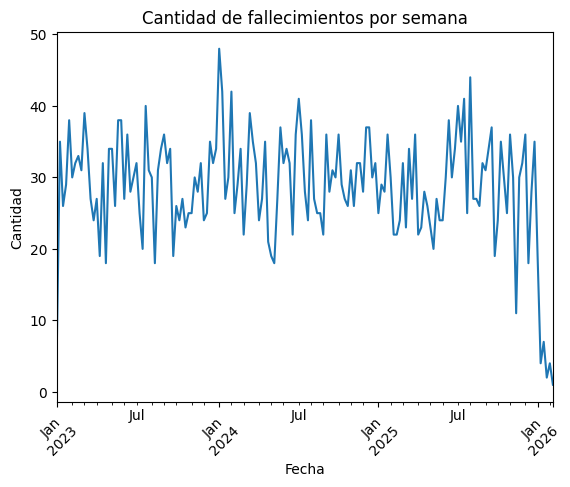

In [273]:
conteo_semanal_defunciones = df_IAE_CDE.set_index('fecha_defuncion').resample('W').size()

plt.figure()
conteo_semanal_defunciones.plot()
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.title("Cantidad de fallecimientos por semana")
plt.xticks(rotation=45)
plt.show()

In [274]:
df_IAE.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19871 entries, 0 to 19883
Data columns (total 47 columns):
 #   Column                                     Non-Null Count  Dtype         
---  ------                                     --------------  -----         
 0   ID                                         15584 non-null  float64       
 1   CEDULA                                     19871 non-null  object        
 2   NOMBRE                                     0 non-null      float64       
 3   APELLIDO                                   0 non-null      float64       
 4   PERSONA                                    19340 non-null  object        
 5   FECHA NACIMIENTO                           15044 non-null  datetime64[ns]
 6   DECISION                                   9710 non-null   object        
 7   PRESTADOR                                  15585 non-null  object        
 8   ESTABLECIMIENTO REGISTRO                   12496 non-null  object        
 9   REGISTRO              

In [275]:
# días que transcurren desde el IAE hasta la muerte. Si la persona no murió se pone nan
df_IAE['DIAS_IAE_MUERTE_'] = (df_IAE["FECHA_DEFUNCION"] - df_IAE["FECHA IAE"])

In [276]:
df_IAE.loc[df_IAE['DIAS_IAE_MUERTE_'].dt.days<0, ['FECHA IAE', 'FECHA_DEFUNCION']]

,FECHA IAE,FECHA_DEFUNCION
12310,2023-05-03,2023-03-09
12688,2023-06-01,2023-02-12
12750,2023-09-04,2023-08-25
12848,2023-08-03,2023-07-28
13019,2023-11-05,2023-05-14
13149,2023-10-06,2023-09-05
13237,2023-11-02,2023-05-13
13240,2023-12-02,2023-06-04
13249,2023-12-03,2023-04-04
13325,2023-11-08,2023-09-28


In [277]:
df_IAE['DIAS_IAE_MUERTE_'].unique()  # días transcurridos desde un IAE hasta muerte

<TimedeltaArray>
[       NaT, '227 days', '834 days', '405 days',  '21 days',  '26 days',
 '353 days',   '1 days',   '2 days', '543 days',
 ...
 '729 days', '617 days', '737 days', '614 days', '429 days', '901 days',
 '214 days', '685 days', '587 days', '106 days']
Length: 317, dtype: timedelta64[ns]

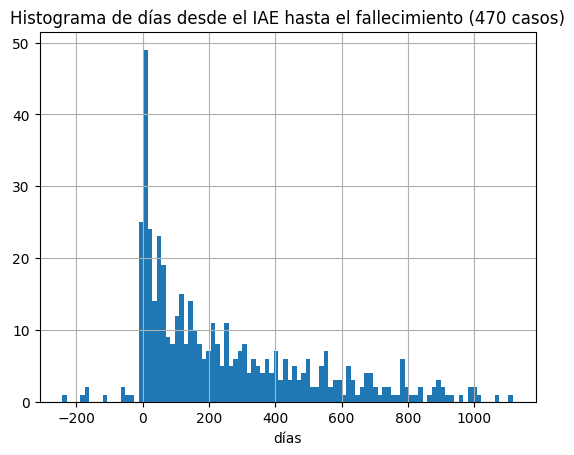

In [278]:
plt.figure()
df_IAE['DIAS_IAE_MUERTE_'].dt.days.hist(bins=100)
n_casos = df_IAE['DIAS_IAE_MUERTE_'].value_counts().sum()
plt.title(f'Histograma de días desde el IAE hasta el fallecimiento ({n_casos} casos)')
plt.xlabel('días')
plt.show()

In [279]:
def moda_o_nan(serie):
    moda = serie.mode()
    return moda.iloc[0] if not moda.empty else None

def min_o_nan(serie):
    minimum = serie.min()
    return minimum

def ultimo_no_nulo(serie):    
    return  serie.dropna().iloc[-1] if not serie.dropna().empty else None

def penultimo_no_nulo(serie):    
    return  serie.dropna().iloc[-2] if len(serie.dropna())>1 else None

def antepenultimo_no_nulo(serie):    
    return  serie.dropna().iloc[-3] if len(serie.dropna())>2 else None

def promedio_entre_intentos(serie):
    s = serie.sort_values()
    # diferencias entre fechas consecutivas
    difs = s.diff().dropna()   # timedeltas
    promedio = difs.mean()     # promedio como timedelta
    promedio = promedio.total_seconds() / 86400 # 86400 segundos en un día

    return promedio

def ultimo_intento(serie):
    s = serie.sort_values()
    ultimo_intento = s.iloc[-1]
    return ultimo_intento

def penultimo_intento(serie):
    s = serie.sort_values()
    penultimo_intento = s.iloc[-2] if len(s)>1 else np.nan
    return penultimo_intento

def antepenultimo_intento(serie):
    s = serie.sort_values()
    antepenultimo_intento = s.iloc[-3] if len(s)>2 else np.nan
    return antepenultimo_intento


In [280]:
df_IAE.groupby("CEDULA").agg(ULTIMO_INTENTO_=("METODO", ultimo_no_nulo))

,ULTIMO_INTENTO_
CEDULA,
0000e681952be7f20878a73707231609bf41c5c8c0a86b0166da88d7ebd012ba,None
0003596f1bde95098ff48b86d0561cb0498b93576221e33bb3da1bf5fabf0ee2,Lesiones autoinfligidas
00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db8d78c72df7ea548a22,Ingesta de Medicamentos
0004278339f5f72aa648112ee2ea5968932e11d34147aa171f5934009af1bb2e,Ahorcamiento o asfixia
00127d6bb76d70724ef073fe967dd80f6b77df38a959ae4dafefff2789cd8326,Ingesta de Medicamentos
...,...
ffdda04d9cb7f61ac16abefb57d895d41381e70cc5098d4576cfa58780f7c357,Ahorcamiento o asfixia
ffe42d723da45d0e54737c67fccc747dcc8aceb73075fb598b755045e8c6ff56,Lesiones autoinfligidas
fff6eeeb39dc05fc78a98f367f478045ccf8835a538565f47ba0949106157136,Ingesta de Medicamentos


In [283]:
df_IAE_procesada = (
    df_IAE.groupby("CEDULA")
      .agg(
          Sexo=("PERSONA", moda_o_nan),
          NACIMIENTO=(campo_nacimiento, moda_o_nan),
          METODO_IAE_FRECUENTE_=("METODO_", moda_o_nan),
          METODO_IAE_PREVIO_=("METODO_", ultimo_no_nulo),
          METODO_IAE_PREVIO_2=("METODO_", penultimo_no_nulo),
          METODO_IAE_PREVIO_3=("METODO_", antepenultimo_no_nulo),
          IAE_PREVIO=("IAE PREVIO", ultimo_no_nulo),
          PRESTADOR_RECODIFICADO=(campo_prestador, ultimo_no_nulo),
          PRESTADOR_PUBLICO_=("PRESTADOR_PUBLICO_", moda_o_nan),
          PRESTADOR_PRIVADO_=("PRESTADOR_PRIVADO_", moda_o_nan),
          REGISTRO=("REGISTRO", ultimo_no_nulo),
          FECHA_IAE=("FECHA IAE", ultimo_no_nulo),
          NUMERO_INTENTOS_=("FECHA IAE", "count"),
          DECISION_=(campo_decision, ultimo_no_nulo),
          DEFUNCION_=("DEFUNCION_", ultimo_no_nulo),
          CAT_SUI_=("CAT_SUI_", ultimo_no_nulo),
          CAT_MCEXSUI_=("CAT_MCEXSUI_", ultimo_no_nulo),
          GRUPO_EDAD_=("GRUPO_EDAD_", ultimo_no_nulo),
          ULTIMO_INTENTO_=("FECHA IAE", ultimo_intento),
          DIAS_PROMEDIO_INTENTOS_=("FECHA IAE", promedio_entre_intentos),
          MIN_DIAS_IAE_MUERTE_=("DIAS_IAE_MUERTE_", min_o_nan),
      )
      .reset_index()
)


In [284]:
df_IAE_procesada['METODO_IAE_PREVIO_3'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 16665 entries, 0 to 16664
Series name: METODO_IAE_PREVIO_3
Non-Null Count  Dtype 
--------------  ----- 
621 non-null    object
dtypes: object(1)
memory usage: 130.3+ KB


In [285]:
df_IAE_procesada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     10313
0      4286
2      1445
3       392
4       112
5        54
6        21
7        19
9         9
8         5
10        3
13        2
12        2
11        1
16        1
Name: count, dtype: int64

In [287]:
df_IAE['DIAS_IAE_MUERTE_'].value_counts()

DIAS_IAE_MUERTE_
0 days      15
2 days      12
4 days      10
9 days       7
1 days       7
            ..
901 days     1
214 days     1
685 days     1
587 days     1
106 days     1
Name: count, Length: 316, dtype: int64

In [288]:
df_IAE_procesada['MIN_DIAS_IAE_MUERTE_'].value_counts()

MIN_DIAS_IAE_MUERTE_
0 days      14
2 days      11
4 days      10
1 days       7
9 days       6
            ..
554 days     1
96 days      1
225 days     1
266 days     1
32 days      1
Name: count, Length: 269, dtype: int64

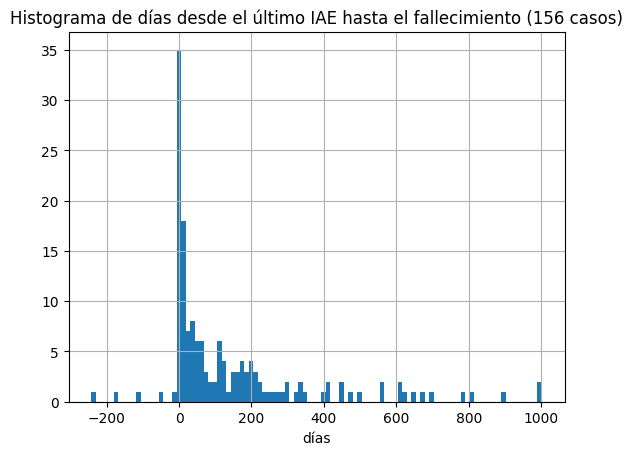

In [853]:
plt.figure()
df_IAE_procesada[df_IAE_procesada['CAT_SUI_']==1]['MIN_DIAS_IAE_MUERTE_'].dt.days.hist(bins=100)
n_casos = df_IAE_procesada[df_IAE_procesada['CAT_SUI_']==1]['MIN_DIAS_IAE_MUERTE_'].value_counts().sum()
plt.title(f'Histograma de días desde el último IAE hasta el fallecimiento ({n_casos} casos)')
plt.xlabel('días')
plt.show()

In [854]:
df_IAE_procesada.head()

,CEDULA,Sexo,NACIMIENTO,METODO_IAE_FRECUENTE_,METODO_IAE_PREVIO_,METODO_IAE_PREVIO_2,METODO_IAE_PREVIO_3,IAE_PREVIO,PRESTADOR_RECODIFICADO,PRESTADOR_PUBLICO_,...,FECHA_IAE,NUMERO_INTENTOS_,DECISION_,DEFUNCION_,CAT_SUI_,CAT_MCEXSUI_,GRUPO_EDAD_,ULTIMO_INTENTO_,DIAS_PROMEDIO_INTENTOS_,MIN_DIAS_IAE_MUERTE_
0,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,None,NaT,None,None,None,None,None,ASSE - HOSPITAL DE CLINICAS,True,...,2025-02-15,1,None,0,NaN,NaN,NaN,2025-02-15,NaN,NaT
1,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,Masculino,2008-02-01,Lesiones autoinfligidas,Lesiones autoinfligidas,None,None,SI,INSTITUTO ASISTENCIAL COLECTIVO IAC | DIRECCIO...,True,...,2023-05-22,1,RESUELTO,0,NaN,NaN,17.5,2023-05-22,NaN,NaT
2,00038a5392a55a75ead4cc22801ce5fb4aa1e94d0b70db...,Femenino,1991-01-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,SI,CIRCULO CATOLICO DE OBREROS DEL URUGUAY,False,...,2024-07-22,1,RESUELTO,0,NaN,NaN,32.5,2024-07-22,NaN,NaT
3,0004278339f5f72aa648112ee2ea5968932e11d34147aa...,Masculino,NaT,LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHOR...,None,None,None,None,None,...,NaT,0,None,1,1.0,1.0,NaN,NaT,NaN,NaT
4,00127d6bb76d70724ef073fe967dd80f6b77df38a959ae...,Femenino,2004-07-01,Ingesta de Medicamentos,Ingesta de Medicamentos,None,None,NO SE INDICA,AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL ...,False,...,2025-07-20,1,None,0,NaN,NaN,22.5,2025-07-20,NaN,NaT


In [855]:
df_IAE_procesada['DIAS_PROMEDIO_INTENTOS_'].unique()

array([           nan, 2.77500000e+01, 1.65000000e+02, 2.50000000e+01,
       2.56500000e+02, 2.48000000e+02, 3.28000000e+02, 1.31200000e+02,
       2.27500000e+02, 6.35000000e+01, 2.70000000e+02, 4.60000000e+02,
       6.90000000e+02, 1.26000000e+02, 1.00000000e+02, 1.10000000e+01,
       1.45000000e+01, 6.30000000e+01, 2.05000000e+02, 3.86500000e+02,
       8.00000000e+00, 1.60000000e+02, 0.00000000e+00, 3.70000000e+01,
       2.90000000e+01, 2.17000000e+02, 4.46000000e+02, 5.20000000e+01,
       4.50000000e+01, 1.00000000e+00, 3.60000000e+02, 2.18000000e+02,
       3.35000000e+02, 1.20000000e+02, 7.00000000e+00, 2.55000000e+02,
       3.60000000e+01, 3.66000000e+02, 3.13500000e+02, 4.28000000e+02,
       4.20000000e+01, 3.10500000e+02, 1.85000000e+02, 5.14000000e+02,
       1.15666667e+02, 2.49000000e+02, 3.80000000e+02, 7.40000000e+01,
       8.17000000e+02, 7.09000000e+02, 2.79000000e+02, 4.65000000e+01,
       3.12000000e+02, 2.61000000e+02, 2.00500000e+02, 4.35000000e+02,
      

In [856]:
np.sum(df_IAE_procesada['DEFUNCION_']==1)

np.int64(4678)

In [857]:
# indices de las personas que están en la base de defunciones pero no están en la de IAE
indices = df_IAE_CDE['cedula'].isin(df_IAE_procesada['CEDULA'])
df_IAE_CDE[~indices]

,cedula,fecha_defuncion,causa_basica_muerte_valor,causa_basica_muerte_descripcion,lugar_ocurrencia,lugar_ocurrencia_detalle,departamento_ocurrencia,edad_fallecimiento_calculada,edad_fallecimiento_digitada,estado_civil,etnia,mayor_nivel_educacion,institucion_fallecio,es_motivo_externo,motivo_externo,motivo_externo_desc,CAT_SUI_,CAT_MCEXSUI_,grupo edades


In [858]:
df_IAE_CDE.shape

(4678, 19)

In [859]:
# Cuadro 2A en el informe
df_IAE_procesada['NUMERO_INTENTOS_'].value_counts()

NUMERO_INTENTOS_
1     10313
0      4286
2      1445
3       392
4       112
5        54
6        21
7        19
9         9
8         5
10        3
13        2
12        2
11        1
16        1
Name: count, dtype: int64

In [860]:
df_IAE_procesada['IAE_PREVIO'].value_counts()

IAE_PREVIO
SI                                                                                             5692
NO                                                                                             4337
NO SE INDICA                                                                                   1870
Tratamiento en el prestador habitual                                                             89
Sin dato                                                                                         25
Tratamiento en clínica privada                                                                    3
                                                                                                  1
Name: count, dtype: int64

In [861]:
df_IAE_procesada['IAE_PREVIO_CORREGIDO' ] = df_IAE_procesada['IAE_PREVIO'].copy()
df_IAE_procesada.loc[(df_IAE_procesada["IAE_PREVIO_CORREGIDO"] == "NO SE INDICA") & (df_IAE_procesada["NUMERO_INTENTOS_"] > 1), "IAE_PREVIO_CORREGIDO"] = "SI"


In [862]:
df_IAE_procesada['IAE_PREVIO_CORREGIDO'].value_counts()

IAE_PREVIO_CORREGIDO
SI                                                                                             5875
NO                                                                                             4337
NO SE INDICA                                                                                   1687
Tratamiento en el prestador habitual                                                             89
Sin dato                                                                                         25
Tratamiento en clínica privada                                                                    3
                                                                                                  1
Name: count, dtype: int64

In [863]:
df_IAE_procesada['METODO_IAE_FRECUENTE_'].value_counts()

METODO_IAE_FRECUENTE_
Ingesta de Medicamentos                                                                                          8828
Ahorcamiento o asfixia                                                                                           1118
LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHORCAMIENTO, ESTRANGULAMIENTO O SOFOCACI�N VIVIENDA                   1114
Otros                                                                                                            1063
Lesiones autoinfligidas                                                                                           969
                                                                                                                 ... 
CA�DA QUE IMPLICA CAMA, LUGAR NO ESPECIFICADO                                                                       1
EXPOSICI�N AL FR�O NATURAL EXCESIVO, OTRO LUGAR ESPECIFICADO                                                        1
CONTACTO CON AGUA CALIENTE CORRIEN

In [864]:
df_IAE_procesada['METODO_IAE_PREVIO_'].value_counts()

METODO_IAE_PREVIO_
Ingesta de Medicamentos                                                                                          8709
Otros                                                                                                            1187
LESI�N AUTOINFLIGIDA INTENCIONALMENTE POR AHORCAMIENTO, ESTRANGULAMIENTO O SOFOCACI�N VIVIENDA                   1115
Ahorcamiento o asfixia                                                                                           1050
Lesiones autoinfligidas                                                                                          1031
                                                                                                                 ... 
CA�DA QUE IMPLICA CAMA, LUGAR NO ESPECIFICADO                                                                       1
EXPOSICI�N AL FR�O NATURAL EXCESIVO, OTRO LUGAR ESPECIFICADO                                                        1
CONTACTO CON AGUA CALIENTE CORRIENTE,

In [865]:
nombre_procesada = 'IAE_procesada_2a_entrega.csv' if 'EH' in dfs.keys() else 'IAE_procesada.csv'
df_IAE_procesada.to_csv(nombre_procesada)

In [866]:
'EH' in dfs.keys()

True

In [867]:
nombre_procesada

'IAE_procesada_2a_entrega.csv'

# Análisis IAE CNV

In [868]:
df_IAE_CNV.shape

(5359, 27)

In [869]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5359 entries, 0 to 5358
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           5359 non-null   object        
 1   anio_mes_nacimiento_hijo         5359 non-null   datetime64[ns]
 2   nro_rese                         5359 non-null   object        
 3   estado_civil                     5359 non-null   object        
 4   pais_nac                         5359 non-null   object        
 5   pais_residencia                  5359 non-null   object        
 6   mayor_nivel_estudio              5359 non-null   object        
 7   sexo                             5359 non-null   object        
 8   peso                             5359 non-null   int64         
 9   semanas_gestacion                5359 non-null   int64         
 10  orden                            5359 non-null   int64      

In [870]:
df_IAE_CNV=df_IAE_CNV.dropna(thresh=2) 

In [871]:
df_IAE_CNV.shape

(5359, 27)

In [872]:
np.sum(df_IAE_CNV['cedula'].isnull())

np.int64(0)

In [873]:
# regionales de ASSE

In [874]:
df_IAE_CNV[df_IAE_CNV['cedula']=='62470455efa50416bcc349b1e52d31b22d00b24af3307c5bf4d417d0dcb90085']

# cantidad de hijos
# edad más pequeño # ¿paridad completa?
# predecir reintento?

,cedula,anio_mes_nacimiento_hijo,nro_rese,estado_civil,pais_nac,pais_residencia,mayor_nivel_estudio,sexo,peso,semanas_gestacion,...,total_consultas,mes_parto,lugar_parto,lugar_depto,tipo_certificador,tipo_parto,tipo_cesarea,forceps,vaccum,otra_maniobra
2749,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2017-10-01,37b4a66381ebbbc409a32c72e4b606ca0d949c581787b7...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2900,40,...,14.0,10.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2750,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2008-04-01,e7d4cfe19c14c154992dc5bdf4b819904f0e90568b9c64...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2420,37,...,9.0,4.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,INTRAPARTO,0.0,0.0,0.0
2751,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2013-05-01,2dc74ac2cfb750ed27ca6c24ece46f833e22d0d5fd056c...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,3110,41,...,5.0,5.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2752,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2020-11-01,3e1f01b53df2685f0df404be47d6abf82be99d708dcc5e...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2180,38,...,12.0,11.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0
2753,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2011-09-01,afc5217fc784b883f588519206e6fffaf969f82a63b082...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,F,3120,38,...,9.0,9.0,1.0,MONTEVIDEO,MEDICO,VAGINAL,,0.0,0.0,0.0
2754,62470455efa50416bcc349b1e52d31b22d00b24af3307c...,2015-09-01,5172857a40eb4189e4e2517654882b048556964096f97b...,SOLTERO/A,URUGUAY,URUGUAY,SECUNDARIA - CICLO BASICO,M,2420,37,...,6.0,9.0,1.0,MONTEVIDEO,MEDICO,CESAREA,ANTEPARTO,0.0,0.0,0.0


In [875]:
df_IAE_CNV['cedula'].value_counts()

cedula
0e6c66043ed8cf01684ea1ffeb1b81b0d6096d18a63dca4fafdc47e8dc77f72e    7
44e39b19e5c363c4b37f1612ed72a5983ffc6b3dedee2ca57e8728c2598e3586    6
0d4942a8d9baba7f9f95c44c72db233281fcc987fecaa3858a44a68f82bbeb40    6
4864459a09c1d5ccb39caf4a87c17a19a8f344aaa3506fbe6a0bc4d3dfb31ccd    6
fc198870f88665e7c7867bee855b485f74c9f89bce2f1ab88e51937f9bbc301e    6
                                                                   ..
9044e99dfa7397bd517766dab1178b06934e65a734d7533e89f49e2081169a1c    1
6bc9a7046f53f17d1295ea09620cd829d80ee1d1b75fdc6be8cc1973eeef3aa3    1
89b56b020597ddb182c77ec7de8c24c18c965eebd6a94a36553ba12b7b3158db    1
79fede789ad1e666bf49303c4a2c4685c8601803f493dde21016fefc8dd91348    1
3293b157df5c85451c754d7889ec5f0f0ced72f84f7bb6d31bbb584785b0d68b    1
Name: count, Length: 3517, dtype: int64

In [876]:
# Hay 41 duplicados
df_IAE_CNV.drop_duplicates(inplace=True)
df_IAE_CNV.shape

(5359, 27)

In [877]:
df_IAE_CNV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5359 entries, 0 to 5358
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   cedula                           5359 non-null   object        
 1   anio_mes_nacimiento_hijo         5359 non-null   datetime64[ns]
 2   nro_rese                         5359 non-null   object        
 3   estado_civil                     5359 non-null   object        
 4   pais_nac                         5359 non-null   object        
 5   pais_residencia                  5359 non-null   object        
 6   mayor_nivel_estudio              5359 non-null   object        
 7   sexo                             5359 non-null   object        
 8   peso                             5359 non-null   int64         
 9   semanas_gestacion                5359 non-null   int64         
 10  orden                            5359 non-null   int64      

In [878]:
np.sum(df_IAE_CNV.duplicated())

np.int64(0)

In [879]:
df_IAE_CNV['anio_mes_nacimiento_hijo'].unique()

<DatetimeArray>
['2015-03-01 00:00:00', '2010-08-01 00:00:00', '2014-01-01 00:00:00',
 '2011-06-01 00:00:00', '2008-04-01 00:00:00', '2012-07-01 00:00:00',
 '2011-03-01 00:00:00', '2008-08-01 00:00:00', '2011-08-01 00:00:00',
 '2021-06-01 00:00:00',
 ...
 '2008-03-01 00:00:00', '2021-12-01 00:00:00', '2022-02-01 00:00:00',
 '2024-06-01 00:00:00', '2024-04-01 00:00:00', '2008-09-01 00:00:00',
 '2024-12-01 00:00:00', '2025-07-01 00:00:00', '2024-03-01 00:00:00',
 '2026-02-01 00:00:00']
Length: 216, dtype: datetime64[ns]

In [880]:
indices = df_IAE_CNV['cedula'].isin(df_IAE_procesada['CEDULA'])
df_IAE_CNV[~indices].shape  # hay 20 cédulas que están en la base de CNV pero no están en la de IAE

(0, 27)

# Análisis IAE RUCAF

In [881]:
df_IAE_RUCAF.shape

(12199, 6)

In [882]:

df_IAE_RUCAF=df_IAE_RUCAF.dropna(thresh=2) 
df_IAE_RUCAF.shape

(12199, 6)

In [883]:
df_IAE_RUCAF.drop_duplicates(inplace=True)  # no hay duplicados en RUCAF
df_IAE_RUCAF.shape

(12199, 6)

In [884]:
df_IAE_RUCAF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12199 entries, 0 to 12198
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cedula        12199 non-null  object
 1   prestador     12199 non-null  object
 2   pais          12199 non-null  object
 3   departamento  12068 non-null  object
 4   localidad     11750 non-null  object
 5   cobertura     12199 non-null  object
dtypes: object(6)
memory usage: 572.0+ KB


In [885]:
df_IAE_RUCAF.head()

,cedula,prestador,pais,departamento,localidad,cobertura
0,d5dece3e533c269e6bb804be9c30ae691f022445351876...,ASOCIACIÓN ESPAÑOLA,UY,MONTEVIDEO,MONTEVIDEO,No Fonasa
1,92df4a0492d70e1f3290d6b96294afe0efbe9ee241055e...,UNIVERSAL,UY,MONTEVIDEO,MONTEVIDEO,Fonasa
2,49c383f277ff2654c9ee599ee802ed2e3b4e822be3451e...,ASSE,UY,MONTEVIDEO,MONTEVIDEO,Fonasa
3,00e2527057fd9126b4c0346916628eaaf756aff82212c5...,ASSE,UY,MALDONADO,MALDONADO,Fonasa
4,8bef653aa6b2a0cbf932a4dc87746292f4ab52e62bf8cc...,SMI,UY,MONTEVIDEO,MONTEVIDEO,Fonasa


In [886]:
df_IAE_RUCAF.prestador.unique()

array(['ASOCIACIÓN ESPAÑOLA', 'UNIVERSAL', 'ASSE', 'SMI',
       'HOSPITAL EVANGELICO', 'MEDICA URUGUAYA', 'COSEM',
       'CIRCULO CATOLICO', 'CAMEDUR', 'AMDM', 'AMSJ', 'SMQS', 'CASMU',
       'COMEPA', 'SANIDAD DE LAS FF.AA', 'COMECA',
       'SWISS MEDICAL URUGUAY (BlueCross - BlueShield de Uruguay)', 'MP',
       'GREMEDA', 'CRAMI', 'HOSPITAL POLICIAL', 'CAMDEL', 'COMERI',
       'CUDAM', 'SEGURO AMERICANO', 'CRAME', 'HOSPITAL BRITANICO',
       'CASA DE GALICIA', 'COMEFLO', 'CAMEC', 'CAMS', 'CASMER', 'CAMCEL',
       'GREMCA', 'COMERO', 'CAAMEPA', 'CAMY', 'COMEF',
       'ASSE - ADMINISTRACION DE SERVICIOS DE SALUD DEL ESTADO',
       'MEDICA URUGUAYA MUCAM',
       'ASOCIACION ESPAÑOLA PRIMERA DE SOCORROS MUTUOS', 'COMECA IAMPP',
       'UNIVERSAL SOCIEDAD DE PRODUCCION SANITARIA',
       'AMDM IAMPP - ASISTENCIAL MEDICA DEPARTAMENTAL DE MALDONADO IAMPP',
       'CASMER IAMPP', 'SERVICIO MEDICO INTEGRAL SMI', 'CRAMI IAMPP',
       'CIRCULO CATOLICO DE OBREROS DEL URUGUAY',
      

In [887]:
df_IAE_RUCAF.pais.value_counts()

pais
UY    12194
AR        2
PE        1
BR        1
CU        1
Name: count, dtype: int64

In [888]:
df_IAE_RUCAF.pais.unique()

array(['UY', 'PE', 'BR', 'AR', 'CU'], dtype=object)

In [889]:
df_IAE_RUCAF.departamento.unique()

array(['MONTEVIDEO', 'MALDONADO', 'CANELONES', 'DURAZNO', 'SAN JOSE',
       'SALTO', 'TREINTA Y TRES', 'PAYSANDU', 'RIO NEGRO', 'RIVERA',
       'ARTIGAS', 'LAVALLEJA', 'CERRO LARGO', nan, 'SORIANO', 'COLONIA',
       'ROCHA', 'FLORES', 'TACUAREMBO', 'FLORIDA'], dtype=object)

In [890]:
df_IAE_RUCAF.cobertura.value_counts()

cobertura
Fonasa       7942
No Fonasa    4257
Name: count, dtype: int64

# Análisis IAE SHARPS

In [891]:
df_IAE_SHARPS.shape

(987, 2)

In [892]:
df_IAE_SHARPS=df_IAE_SHARPS.dropna(thresh=2) 
df_IAE_SHARPS.shape

(987, 2)

In [893]:
df_IAE_SHARPS.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 987 entries, 0 to 986
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   cedula  987 non-null    object
 1   titulo  987 non-null    object
dtypes: object(2)
memory usage: 15.6+ KB


In [894]:
df_IAE_SHARPS.titulo

0      LICENCIADO EN PSICOLOGIA                      ...
1      LICENCIADO EN IMAGENOLOGIA                    ...
2      TECNICO EN HEMOTERAPIA                        ...
3      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
4      AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
                             ...                        
982    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
983    AUXILIAR DE SERVICIO, TISANERIA Y AYUDANTE DE ...
984    AUXILIAR DE ENFERMERÍA INTEGRAL               ...
985    AUXILIAR DE ENFERMERÍA                        ...
986    AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISA...
Name: titulo, Length: 987, dtype: object

In [895]:
np.sum(df_IAE_SHARPS.duplicated())

np.int64(0)

In [896]:
len(df_IAE_SHARPS['titulo'].unique())

104

In [897]:
df_IAE_SHARPS['titulo'].value_counts()

titulo
AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISANERÍA                                                                                                                                                                                                                132
AUXILIAR DE ENFERMERIA INTEGRAL                                                                                                                                                                                                                                     98
AUXILIAR DE ENFERMERÍA INTEGRAL                                                                                                                                                                                                                                     95
AUXILIAR DE SERVICIO AYUDANTE DE COCINA Y TISANERIA                                                                                                                                                         

# Análisis IAE SIV

In [899]:
df_IAE_SIV.shape

(206117, 4)

In [900]:
df_IAE_SIV=df_IAE_SIV.dropna(thresh=2) 
df_IAE_SIV.shape

(206117, 4)

In [901]:
np.sum(df_IAE_SIV.duplicated())  # hay 231 duplicados en esta base

np.int64(0)

In [902]:
df_IAE_SIV.drop_duplicates(inplace=True)

In [903]:
df_IAE_SIV.shape

(206117, 4)

In [904]:
indices = df_IAE_SIV['cedula'].isin(df_IAE_procesada['CEDULA'])  # 201 casos están en la base SIV pero no en la de IAE
df_IAE_SIV[~indices]

,cedula,fecha,descripcion,dosis


In [905]:
df_IAE_SIV.head()

,cedula,fecha,descripcion,dosis
0,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,2021-03-29,COVID 19 - CORONAVAC,1
1,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,2021-04-26,COVID 19 - CORONAVAC,2
2,0000e681952be7f20878a73707231609bf41c5c8c0a86b...,2021-09-07,COVID 19 - PFIZER-BIONTECH,3
3,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2008-02-27,BCG,1
4,0003596f1bde95098ff48b86d0561cb0498b93576221e3...,2008-04-28,ANTINEUMOCÓCICA CONJUGADA 7,1


In [906]:
df_IAE_SIV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206117 entries, 0 to 206116
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   cedula       206117 non-null  object        
 1   fecha        206117 non-null  datetime64[ns]
 2   descripcion  206117 non-null  object        
 3   dosis        206117 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 6.3+ MB


In [907]:
np.sum(df_IAE_SIV.duplicated())

np.int64(0)

In [908]:
df_IAE_SIV.cedula.value_counts()

cedula
902a99871d14696073b4c2314fbaa822aea95ef3cffe19ebaae5168919e3e0a1    42
24882918a56db014b63afa8aef1bc3c74ee9aa3daf60151b893ee7384716c639    39
39a3a215244cbeaa30a338cb5d3d0ee321f301be97bb02a7aca4ef350cabbedd    37
f6c8b6034f539dc2bba8cd6961b369bf19d0dbe3488e067d20ff222c6c377e6f    36
e085b0fffca1ade684568be040784deb9333a17afedd7022e1c996c3b6e221e2    36
                                                                    ..
8ed8a208de57785688958bc3e85dd2e8f6c9b7e75a70cc55b6be5881eb5ac305     1
f9685febd6e824a239236e252b499d751b230d46d34f431a120e5378ad1747cd     1
75b122a1b5d3b9ea4dc7291644a55176a955a14da7a7fec6b7dda4c8d38077f7     1
0508064c7f183f81ebcb57d99588f243aa91c3f16242b53c2b3d0f521fee2831     1
d8f34bc652ee3e5b3a32fdacfd4cc83ef5f026ed7dec5dce88883dbefbe7de51     1
Name: count, Length: 16125, dtype: int64

In [909]:
len(df_IAE_SIV.cedula.unique())

16125

In [910]:
df_IAE_SIV.descripcion.value_counts()

descripcion
ANTIPOLIOMELÍTICA (VPO)                              28662
COVID 19 - PFIZER-BIONTECH                           28010
PENTAVALENTE (DPT,HB/Hib)                            19406
TRIPLE BACTERIANA (Difteria,Tétanos,Tos convulsa)    16687
TRIPLE VIRAL (Sarampión,Rubeola,Paperas)             14538
                                                     ...  
MENINGOCOCO A+C                                          2
ROTAVIRUS 1S                                             2
COVID 19 - SPUTNIK V                                     1
HEPATITIS A Y FIEBRE TIFOIDEA                            1
DOBLE VIRAL (SR)                                         1
Name: count, Length: 65, dtype: int64

In [911]:
len(df_IAE_SIV.descripcion.unique())

65

In [912]:
df_IAE_SIV.dosis.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 21, 11, 10, 12, 31, 13, 16])

# Análisis IAE EH

In [401]:
df_IAE_EH.shape

(14696, 21)

In [402]:
df_IAE_EH.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14696 entries, 0 to 14695
Data columns (total 21 columns):
 #   Column                                         Non-Null Count  Dtype         
---  ------                                         --------------  -----         
 0   cedula                                         14696 non-null  object        
 1   Institución                                    14696 non-null  object        
 2   Sector                                         14696 non-null  object        
 3   Fecha ingreso                                  14696 non-null  datetime64[ns]
 4   Fecha Egreso                                   14696 non-null  datetime64[ns]
 5   Diagnostico principal según CIE-10             14696 non-null  object        
 6   Causa externa según CIE-10                     4428 non-null   object        
 7   Diagnóstico complementario según CIE-10) 3     6019 non-null   object        
 8   Diagnóstico complementario según CIE-10) 4     1808 non-

In [403]:
df_IAE_EH['Diagnóstico complementario según CIE-10) 4'].value_counts()

Diagnóstico complementario según CIE-10) 4
Z91.5    165
R45.8     85
I10       68
F60.9     58
F32.9     58
        ... 
Z65.3      1
W44.9      1
T11.1      1
R69        1
Z74.0      1
Name: count, Length: 527, dtype: int64

In [406]:
df_IAE_EH['Fecha ingreso'].value_counts()

Fecha ingreso
2024-10-15    41
2024-10-10    37
2024-08-26    36
2024-01-04    35
2023-04-20    35
              ..
1986-04-08     1
2024-12-31     1
2022-11-12     1
2022-11-03     1
2022-12-14     1
Name: count, Length: 774, dtype: int64

In [404]:
df_IAE_EH['Egreso'].value_counts()

Egreso
ALTA         13972
FALLECIDO      724
Name: count, dtype: int64

## Merge de las bases

In [722]:
dfs = [
    (df_IAE_procesada, "CEDULA"),
    (df_IAE_CDE, "cedula"),
   # (df_IAE_CNV, "cedula"),
   # (df_IAE_RUCAF, "cedula"),
   # (df_IAE_SHARPS, "cedula"),
    #(df_IAE_SIV, "cedula")
]

# merge inicial
df_merge = dfs[0][0]

# merges sucesivos
for df, key in dfs[1:]:
    #print(df_merge.keys())
    df_merge = df_merge.merge(df, left_on=dfs[0][1], right_on=key, how="outer")
    df_merge.drop(columns=[c for c in df_merge.columns if c.endswith("_x") or c.endswith("_y")],
            inplace=True, errors="ignore")
    print(df_merge.shape, len(df_merge['CEDULA'].unique()))
    #print(df_merge.head())

df_merge.to_csv('merge.csv')

(16665, 38) 16665


In [ ]:
df_IAE_procesada.shape, df_merge.shape

In [ ]:
df_merge[df_merge['CEDULA'].isnull()]

In [ ]:
len(df_merge['CEDULA'].unique())

In [ ]:
#grouped = df_merge.groupby('CEDULA')
df_grouped = df_merge.groupby("CEDULA").agg(list).reset_index()
df_grouped.to_csv('merge_grouped.csv')

In [ ]:
df_grouped.shape